# Локальная идентификация СДУ как ранний сигнал критического перехода

Проверяется, можно ли по короткому временному ряду отличить потерю устойчивости от роста случайных возмущений, если оба механизма увеличивают дисперсию:

$$
dX_t=-\kappa_tX_t\,dt+\sigma_t\,dW_t,
\qquad
\operatorname{Var}(X_t)\approx\frac{\sigma_t^2}{2\kappa_t}.
$$

Ноутбук включает синтетические эксперименты для линейных и нелинейных систем, сравнение локальных оценивателей и проверку на данных ОРВИ и COVID-19.

## Дизайн эксперимента

Сравниваются стационарный контроль, снижение $\kappa_t$ и рост $\sigma_t$. В двух нестационарных сценариях теоретическая дисперсия совпадает, поэтому различение должно опираться не только на ее рост.

Наблюдения могут содержать шум измерения, пропуски и разную частоту регистрации. Локальная OU-оценка использует связь с AR(1):

$$
\phi=e^{-\kappa\Delta t},\qquad
\widehat\kappa=-\frac{\log\widehat\phi}{\Delta t}.
$$


In [1]:
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Dict, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn

from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize

SEED = 20260910
rng = np.random.default_rng(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})

SCENARIO_LABELS = {
    "stationary": "Стационарный контроль",
    "stability_loss": "Потеря устойчивости",
    "noise_growth": "Рост случайных возмущений",
}

In [2]:
@dataclass(frozen=True)
class ExperimentConfig:
    horizon: float = 100.0
    transition_time: float = 80.0
    latent_dt: float = 0.05
    kappa_initial: float = 0.80
    kappa_before_transition: float = 0.10
    process_sigma: float = 0.20
    observation_stride: int = 4
    measurement_noise_sd: float = 0.03
    missing_fraction: float = 0.0
    window_width: float = 16.0


BASE_CONFIG = ExperimentConfig()


def smoothstep(progress: np.ndarray) -> np.ndarray:
    # Плавная траектория 0 -> 1 без изломов на границах.
    p = np.clip(progress, 0.0, 1.0)
    return p * p * (3.0 - 2.0 * p)


def scenario_parameters(
    time: np.ndarray,
    scenario: str,
    cfg: ExperimentConfig,
) -> tuple[np.ndarray, np.ndarray]:
    # Возвращает истинные kappa(t) и sigma(t).
    transition_progress = smoothstep(time / cfg.transition_time)
    declining_kappa = (
        cfg.kappa_initial
        - (cfg.kappa_initial - cfg.kappa_before_transition) * transition_progress
    )

    if scenario == "stationary":
        kappa = np.full_like(time, cfg.kappa_initial)
        sigma = np.full_like(time, cfg.process_sigma)
    elif scenario == "stability_loss":
        kappa = declining_kappa
        sigma = np.full_like(time, cfg.process_sigma)
    elif scenario == "noise_growth":
        kappa = np.full_like(time, cfg.kappa_initial)
        # sigma^2 / (2*kappa) совпадает со stability_loss в каждый момент.
        sigma = cfg.process_sigma * np.sqrt(cfg.kappa_initial / declining_kappa)
    else:
        raise ValueError(f"Неизвестный сценарий: {scenario}")

    return kappa, sigma


def simulate_latent_process(
    scenario: str,
    cfg: ExperimentConfig,
    random_state: np.random.Generator,
) -> pd.DataFrame:
    # Симулирует локально-точный переход OU при медленных параметрах.
    time = np.arange(0.0, cfg.horizon + cfg.latent_dt / 2, cfg.latent_dt)
    kappa, sigma = scenario_parameters(time, scenario, cfg)
    state = np.empty_like(time)
    state[0] = random_state.normal(
        scale=sigma[0] / np.sqrt(2.0 * kappa[0])
    )

    for i in range(1, len(time)):
        phi = np.exp(-kappa[i - 1] * cfg.latent_dt)
        innovation_var = (
            sigma[i - 1] ** 2
            * (1.0 - phi**2)
            / (2.0 * kappa[i - 1])
        )
        state[i] = phi * state[i - 1] + random_state.normal(
            scale=np.sqrt(innovation_var)
        )

    return pd.DataFrame(
        {"time": time, "state": state, "kappa_true": kappa, "sigma_true": sigma}
    )


def observe_process(
    latent: pd.DataFrame,
    cfg: ExperimentConfig,
    random_state: np.random.Generator,
) -> pd.DataFrame:
    # Дискретизирует ряд, добавляет шум измерений и MCAR-пропуски.
    observed = latent.iloc[:: cfg.observation_stride].copy().reset_index(drop=True)
    observed["value"] = observed["state"] + random_state.normal(
        scale=cfg.measurement_noise_sd,
        size=len(observed),
    )

    if cfg.missing_fraction > 0:
        missing = random_state.random(len(observed)) < cfg.missing_fraction
        missing[[0, -1]] = False
        observed.loc[missing, "value"] = np.nan

    return observed


def simulate_observations(
    scenario: str,
    cfg: ExperimentConfig,
    random_state: np.random.Generator,
) -> pd.DataFrame:
    latent = simulate_latent_process(scenario, cfg, random_state)
    return observe_process(latent, cfg, random_state)

In [3]:
def estimate_local_dynamics(
    time: np.ndarray,
    values: np.ndarray,
    window_end: float,
    window_width: float,
    measurement_noise_sd: float,
) -> Dict[str, float]:
    # Оценивает классические EWS и локальные параметры OU в одном окне.
    # Пропуски не интерполируются: лаговая ковариация использует только пары
    # соседних реально наблюдавшихся значений.
    in_window = (time > window_end - window_width) & (time <= window_end)
    t = np.asarray(time[in_window], dtype=float)
    y = np.asarray(values[in_window], dtype=float)
    finite = np.isfinite(y)

    result = {
        "window_end": window_end,
        "n_observed": int(finite.sum()),
        "variance": np.nan,
        "ar1": np.nan,
        "skewness": np.nan,
        "recovery_rate": np.nan,
        "coefficient_variation": np.nan,
        "kappa_hat": np.nan,
        "sigma_hat": np.nan,
    }
    if finite.sum() < 12 or len(t) < 3:
        return result

    center = np.nanmean(y)
    centered = y - center
    observed_variance = np.nanvar(y, ddof=1)
    observed_sd = np.sqrt(observed_variance)
    third_moment = np.nanmean(centered**3)

    adjacent = finite[:-1] & finite[1:]
    if adjacent.sum() < 8 or observed_variance <= 0:
        return result

    lag_covariance = np.mean(centered[:-1][adjacent] * centered[1:][adjacent])
    dt_observed = float(np.median(np.diff(t)))
    latent_variance = observed_variance - measurement_noise_sd**2

    ar1 = lag_covariance / observed_variance
    result.update(
        variance=observed_variance,
        ar1=ar1,
        skewness=(third_moment / observed_sd**3 if observed_sd > 0 else np.nan),
        recovery_rate=(np.log(ar1) / dt_observed if ar1 > 0 else np.nan),
        coefficient_variation=(
            observed_sd / abs(center)
            if observed_sd > 0 and abs(center) > 0.1 * observed_sd
            else np.nan
        ),
    )

    if latent_variance <= 0:
        return result

    phi = lag_covariance / latent_variance
    if not 0.0 < phi < 1.0:
        return result

    kappa_hat = -np.log(phi) / dt_observed
    sigma_hat = np.sqrt(2.0 * kappa_hat * latent_variance)
    result.update(kappa_hat=kappa_hat, sigma_hat=sigma_hat)
    return result


def rolling_estimates(
    observed: pd.DataFrame,
    cfg: ExperimentConfig,
    window_ends: Iterable[float],
) -> pd.DataFrame:
    rows = [
        estimate_local_dynamics(
            observed["time"].to_numpy(),
            observed["value"].to_numpy(),
            window_end,
            cfg.window_width,
            cfg.measurement_noise_sd,
        )
        for window_end in window_ends
    ]
    return pd.DataFrame(rows)

## Карта эксперимента и правила сравнения

| Задача | Семейства моделей | Что сравнивается |
|---|---|---|
| Синтетическая идентификация | Классические EWS, Moment OU, Kalman OU, SINDy, Bayesian SINDy, две версии Neural SDE | $\kappa$, $\sigma$, $\tau$, PIP, покрытие интервалов, различение механизмов и метрики тревог |
| Нелинейные нормальные формы | Седло-узел, транскритическая и бистабильная системы; диффузия, зависящая от состояния | те же модели, окна и горизонты; устойчивость результатов к форме сноса |
| Классификация начала волны ОРВИ | Decision Tree, Random Forest, Easy Ensemble, RUSBoost, Balanced Bagging, EWSNet | Accuracy, precision, recall, F1 и PR-AUC на горизонтах 4 и 5 недель |
| Прогнозирование COVID-индикаторов | Persistence, Local Kalman-OU, LSTM, GRU | MAE, RMSE, нормированные ошибки, $R^2$, оценивание со скользящим началом, прямой, рекурсивный и многовыходной прогнозы |

Во всех экспериментах используется хронологическое разбиение. Масштабирование
и пороги оцениваются без тестовой выборки, пропуски не интерполируются по всему
ряду, а модели получают одинаковые даты формирования и проверки прогноза. Доля
успешных оценок указывается отдельно: неудачная оценка не считается отсутствием
сигнала.

# Часть I. Контролируемый синтетический сравнительный эксперимент

## 1. Проверка конструкции: одинаковая дисперсия, разные механизмы

Сначала аналитически проверяется совпадение теоретических дисперсий. После
этого различия оценок $\kappa$ и $\sigma$ можно связывать с механизмом, а не с
исходно различной сложностью сценариев.

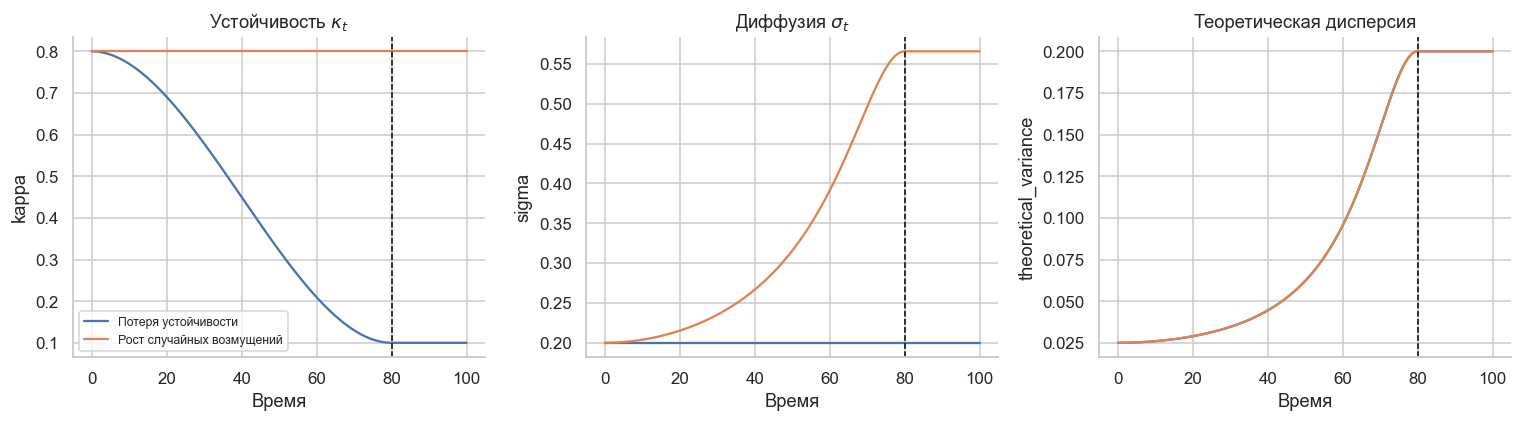

In [4]:
time_grid = np.linspace(0, BASE_CONFIG.horizon, 1001)
parameter_rows = []
for scenario in ["stability_loss", "noise_growth"]:
    kappa, sigma = scenario_parameters(time_grid, scenario, BASE_CONFIG)
    parameter_rows.append(
        pd.DataFrame({
            "time": time_grid,
            "scenario": SCENARIO_LABELS[scenario],
            "kappa": kappa,
            "sigma": sigma,
            "theoretical_variance": sigma**2 / (2.0 * kappa),
        })
    )
parameters = pd.concat(parameter_rows, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, column, title in zip(
    axes,
    ["kappa", "sigma", "theoretical_variance"],
    [r"Устойчивость $\kappa_t$", r"Диффузия $\sigma_t$", "Теоретическая дисперсия"],
):
    sns.lineplot(parameters, x="time", y=column, hue="scenario", ax=ax)
    ax.axvline(BASE_CONFIG.transition_time, color="black", ls="--", lw=1)
    ax.set_title(title)
    ax.set_xlabel("Время")
    if ax is not axes[0] and ax.get_legend() is not None:
        ax.get_legend().remove()
axes[0].legend(title="", fontsize=8)
plt.tight_layout()
plt.show()

variance_pivot = parameters.pivot(
    index="time", columns="scenario", values="theoretical_variance"
)
max_variance_difference = variance_pivot.diff(axis=1).iloc[:, -1].abs().max()

Расхождение теоретических дисперсий находится на уровне машинной точности. По одной дисперсии нельзя отличить потерю устойчивости от роста шума; нужны отдельные оценки $\kappa$ и $\sigma$.

## 2. Одна реализация: данные для локального оценивания

Пунктиром обозначен условный момент перехода $t_c$. Для раннего предупреждения
используются только окна, завершившиеся до него. Отдельная траектория служит
для диагностики; выводы основаны на эксперименте Монте-Карло.

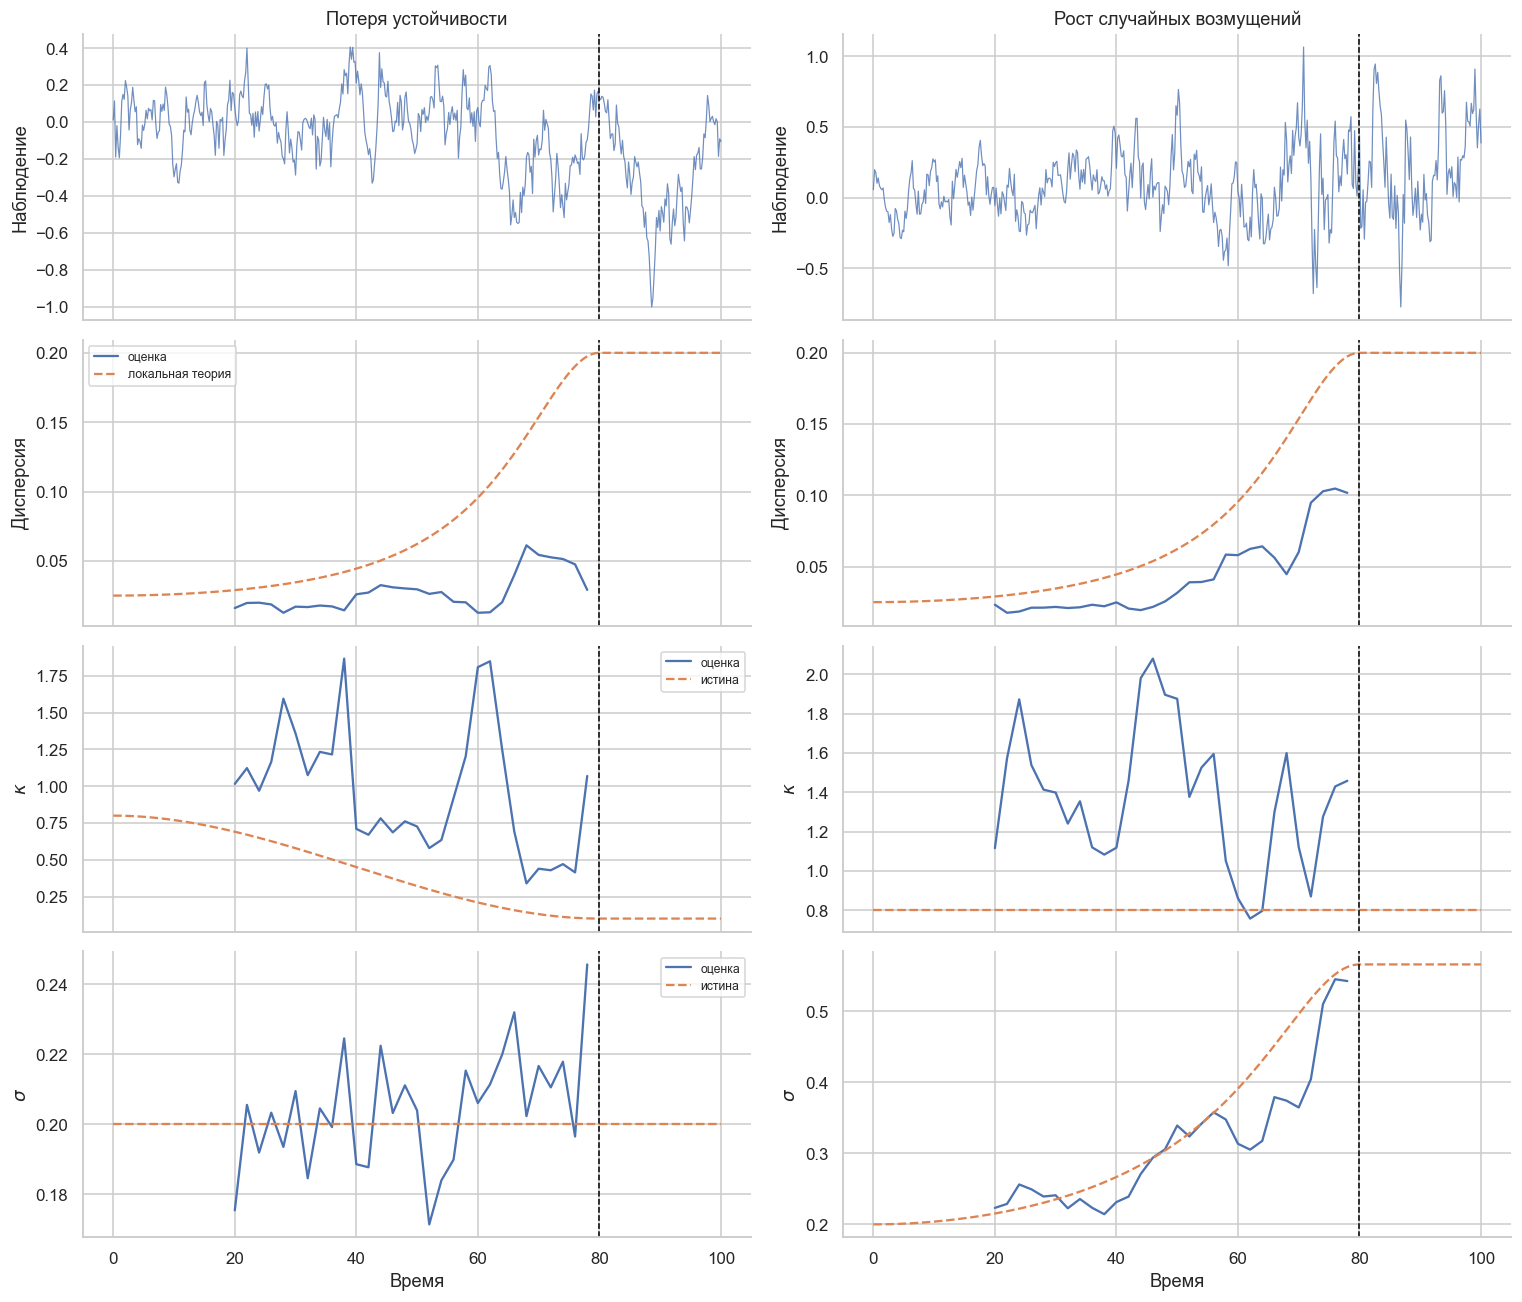

In [5]:
illustration_rng = np.random.default_rng(148)
window_ends = np.arange(20.0, BASE_CONFIG.transition_time, 2.0)

fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex="col")
for column, scenario in enumerate(["stability_loss", "noise_growth"]):
    observed = simulate_observations(scenario, BASE_CONFIG, illustration_rng)
    estimates = rolling_estimates(observed, BASE_CONFIG, window_ends)

    axes[0, column].plot(observed["time"], observed["value"], lw=0.8, alpha=0.8)
    axes[0, column].set_title(SCENARIO_LABELS[scenario])
    axes[0, column].set_ylabel("Наблюдение")

    axes[1, column].plot(estimates["window_end"], estimates["variance"], label="оценка")
    axes[1, column].plot(
        observed["time"],
        observed["sigma_true"] ** 2 / (2 * observed["kappa_true"]),
        ls="--", label="локальная теория",
    )
    axes[1, column].set_ylabel("Дисперсия")

    axes[2, column].plot(estimates["window_end"], estimates["kappa_hat"], label="оценка")
    axes[2, column].plot(observed["time"], observed["kappa_true"], ls="--", label="истина")
    axes[2, column].set_ylabel(r"$\kappa$")

    axes[3, column].plot(estimates["window_end"], estimates["sigma_hat"], label="оценка")
    axes[3, column].plot(observed["time"], observed["sigma_true"], ls="--", label="истина")
    axes[3, column].set_ylabel(r"$\sigma$")
    axes[3, column].set_xlabel("Время")

    for row in range(4):
        axes[row, column].axvline(BASE_CONFIG.transition_time, color="black", ls="--", lw=1)
        if column == 0:
            handles, labels = axes[row, column].get_legend_handles_labels()
            if handles:
                axes[row, column].legend(fontsize=8)

plt.tight_layout()
plt.show()

На отдельной траектории дисперсия растет в обоих сценариях, тогда как оценка $\sigma$ лучше выделяет рост шума. Оценка $\kappa$ заметно колеблется, поэтому выводы далее основаны на повторных симуляциях.

## 3. Эксперимент Монте-Карло

Для каждой комбинации «режим наблюдений × сценарий» моделируется 120
независимых траекторий. Оценки сравниваются между ранним окном ($t=25$) и
последним полностью предкритическим окном ($t=78$).

Рассчитываются изменения классических сигналов раннего предупреждения и
параметров СДУ:

- `variance_change` - изменение скользящей дисперсии;
- `ar1_change` - изменение лаговой автокорреляции первого порядка;
- `recovery_rate_change` - приближение скорости восстановления к нулю;
- `log_cv_change` - изменение $\log(1+CV)$; коэффициент вариации не определен
  при среднем, близком к нулю, поэтому доля успешных оценок указана отдельно;
- `skewness_change` - изменение асимметрии;
- `kappa_decline` - снижение локальной устойчивости;
- `sigma_growth` - рост интенсивности процессного шума.

In [6]:
CONDITIONS = {
    "baseline": BASE_CONFIG,
    "short_window": replace(BASE_CONFIG, window_width=8.0),
    "sparse": replace(BASE_CONFIG, observation_stride=16),
    "measurement_noise": replace(BASE_CONFIG, measurement_noise_sd=0.12),
    "missing_30%": replace(BASE_CONFIG, missing_fraction=0.30),
    "combined": replace(
        BASE_CONFIG,
        observation_stride=16,
        measurement_noise_sd=0.12,
        missing_fraction=0.30,
    ),
}


def extract_change_features(
    observed: pd.DataFrame,
    cfg: ExperimentConfig,
    early_end: float = 25.0,
    late_end: float = 78.0,
) -> Dict[str, float]:
    early = estimate_local_dynamics(
        observed["time"].to_numpy(), observed["value"].to_numpy(),
        early_end, cfg.window_width, cfg.measurement_noise_sd,
    )
    late = estimate_local_dynamics(
        observed["time"].to_numpy(), observed["value"].to_numpy(),
        late_end, cfg.window_width, cfg.measurement_noise_sd,
    )
    return {
        "variance_change": late["variance"] - early["variance"],
        "ar1_change": late["ar1"] - early["ar1"],
        "recovery_rate_change": late["recovery_rate"] - early["recovery_rate"],
        "log_cv_change": (
            np.log1p(late["coefficient_variation"])
            - np.log1p(early["coefficient_variation"])
        ),
        "skewness_change": late["skewness"] - early["skewness"],
        "kappa_decline": early["kappa_hat"] - late["kappa_hat"],
        "sigma_growth": late["sigma_hat"] - early["sigma_hat"],
    }


def run_monte_carlo(
    conditions: Dict[str, ExperimentConfig],
    n_repetitions: int = 120,
    seed: int = SEED,
) -> pd.DataFrame:
    random_state = np.random.default_rng(seed)
    rows = []
    for condition_name, cfg in conditions.items():
        for scenario in SCENARIO_LABELS:
            for repetition in range(n_repetitions):
                observed = simulate_observations(scenario, cfg, random_state)
                features = extract_change_features(observed, cfg)
                rows.append({
                    "condition": condition_name,
                    "scenario": scenario,
                    "repetition": repetition,
                    **features,
                })
    return pd.DataFrame(rows)


monte_carlo = run_monte_carlo(CONDITIONS)
validity = (
    monte_carlo.groupby(["condition", "scenario"])
    [["kappa_decline", "sigma_growth"]]
    .apply(lambda frame: frame.notna().mean())
    .round(3)
)


#### Доля траекторий с допустимой локальной оценкой

In [7]:
display(validity)

kappa_decline  sigma_growth
condition         scenario                                   
baseline          noise_growth            1.000         1.000
                  stability_loss          1.000         1.000
                  stationary              1.000         1.000
combined          noise_growth            0.317         0.317
                  stability_loss          0.267         0.267
                  stationary              0.275         0.275
measurement_noise noise_growth            0.958         0.958
                  stability_loss          0.867         0.867
                  stationary              0.742         0.742
missing_30%       noise_growth            0.933         0.933
                  stability_loss          0.833         0.833
                  stationary              0.950         0.950
short_window      noise_growth            1.000         1.000
                  stability_loss          1.000         1.000
                  stationary              1.000         1.000
sparse            noise_growth            0.917         0.917
                  stability_loss          0.933         0.933
                  stationary              0.950         0.950

В базовом режиме оценки получены для всех траекторий, а в комбинированном — менее чем для трети. Поэтому качество классификации далее рассматривается вместе с долей успешных оценок.

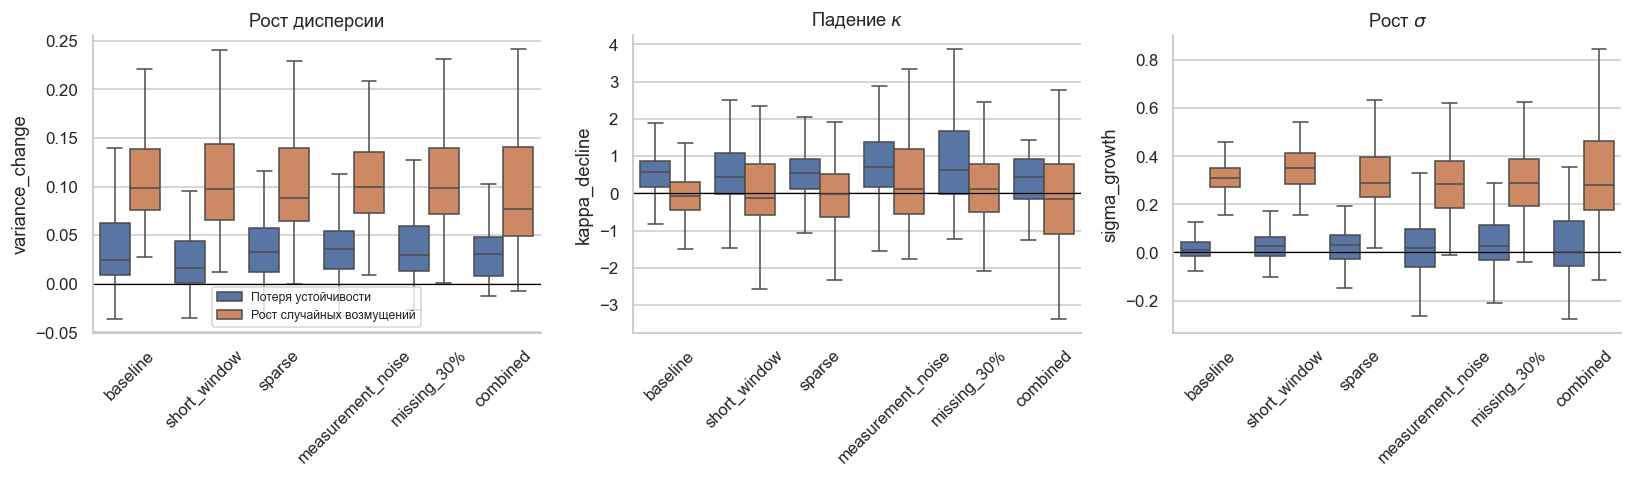

In [8]:
plot_data = monte_carlo.query("scenario != 'stationary'").copy()
plot_data["Сценарий"] = plot_data["scenario"].map(SCENARIO_LABELS)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric, title in zip(
    axes,
    ["variance_change", "kappa_decline", "sigma_growth"],
    ["Рост дисперсии", r"Падение $\kappa$", r"Рост $\sigma$"],
):
    sns.boxplot(
        plot_data, x="condition", y=metric, hue="Сценарий",
        showfliers=False, ax=ax,
    )
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    if ax is not axes[0] and ax.get_legend() is not None:
        ax.get_legend().remove()
axes[0].legend(title="", fontsize=8)
plt.tight_layout()
plt.show()

Рост дисперсии наблюдается при обоих механизмах. Снижение $\kappa$ и рост $\sigma$ разделяют их лучше, хотя распределения признаков перекрываются.

## 4. Последовательная тревога: ложные срабатывания, пропуски и упреждение

Для каждого ряда строится последовательный показатель относительно первого
окна:

- классический показатель: $\widehat{Var}_t-\widehat{Var}_{ref}$;
- показатель локальной СДУ: $\widehat\kappa_{ref}-\widehat\kappa_t$.

Порог в каждом режиме равен 95-му перцентилю максимального предкритического
показателя на стационарных траекториях. Калибровка ограничивает вероятность
хотя бы одной ложной тревоги на всем интервале, а не в отдельной точке.

In [9]:
ALARM_WINDOW_ENDS = np.arange(30.0, BASE_CONFIG.transition_time, 4.0)


def trajectory_scores(
    observed: pd.DataFrame,
    cfg: ExperimentConfig,
) -> pd.DataFrame:
    estimates = rolling_estimates(observed, cfg, ALARM_WINDOW_ENDS)
    reference = estimates.iloc[0]
    estimates["classic_score"] = estimates["variance"] - reference["variance"]
    estimates["sde_score"] = reference["kappa_hat"] - estimates["kappa_hat"]
    return estimates


def alarm_benchmark(
    conditions: Dict[str, ExperimentConfig],
    n_repetitions: int = 80,
    seed: int = SEED + 1,
) -> pd.DataFrame:
    random_state = np.random.default_rng(seed)
    output = []

    for condition_name, cfg in conditions.items():
        paths = {}
        for scenario in SCENARIO_LABELS:
            paths[scenario] = [
                trajectory_scores(
                    simulate_observations(scenario, cfg, random_state), cfg
                )
                for _ in range(n_repetitions)
            ]

        thresholds = {}
        for method, score_column in {
            "Classic variance": "classic_score",
            "Local SDE": "sde_score",
        }.items():
            null_maxima = [path[score_column].max(skipna=True) for path in paths["stationary"]]
            thresholds[method] = float(np.nanquantile(null_maxima, 0.95))

            for scenario in SCENARIO_LABELS:
                alarm_times = []
                for path in paths[scenario]:
                    crossed = path.loc[path[score_column] > thresholds[method], "window_end"]
                    alarm_times.append(float(crossed.iloc[0]) if len(crossed) else np.nan)

                alarm_times = np.asarray(alarm_times)
                detected = np.isfinite(alarm_times)
                eligible = np.asarray([
                    path[score_column].notna().sum() >= 2 for path in paths[scenario]
                ])
                output.append({
                    "condition": condition_name,
                    "method": method,
                    "scenario": scenario,
                    "alarm_rate": detected.mean(),
                    "miss_rate": 1.0 - detected.mean(),
                    "score_coverage": eligible.mean(),
                    "median_lead_time": (
                        cfg.transition_time - np.nanmedian(alarm_times)
                        if detected.any() else np.nan
                    ),
                    "threshold": thresholds[method],
                })

    return pd.DataFrame(output)


alarm_results = alarm_benchmark(CONDITIONS)

summary = (
    alarm_results.pivot_table(
        index=["condition", "method"],
        columns="scenario",
        values="alarm_rate",
    )
    .rename(columns={
        "stationary": "false_alarm_stationary",
        "stability_loss": "detection_stability_loss",
        "noise_growth": "false_alarm_noise_growth",
    })
    .join(
        alarm_results.query("scenario == 'stability_loss'")
        .set_index(["condition", "method"])
        [["median_lead_time", "score_coverage"]]
    )
    .reset_index()
)

display(
    summary.style.format({
        "false_alarm_stationary": "{:.1%}",
        "detection_stability_loss": "{:.1%}",
        "false_alarm_noise_growth": "{:.1%}",
        "score_coverage": "{:.1%}",
        "median_lead_time": "{:.1f}",
    }).background_gradient(
        subset=["detection_stability_loss"], cmap="Greens", vmin=0, vmax=1
    )
)

,condition,method,false_alarm_noise_growth,detection_stability_loss,false_alarm_stationary,median_lead_time,score_coverage
0,baseline,Classic variance,100.0%,80.0%,5.0%,18.0,100.0%
1,baseline,Local SDE,8.8%,22.5%,5.0%,30.0,100.0%
2,combined,Classic variance,58.8%,45.0%,3.8%,18.0,68.8%
3,combined,Local SDE,3.8%,5.0%,2.5%,46.0,45.0%
4,measurement_noise,Classic variance,100.0%,91.2%,5.0%,18.0,100.0%
5,measurement_noise,Local SDE,5.0%,5.0%,5.0%,38.0,86.2%
6,missing_30%,Classic variance,97.5%,83.8%,5.0%,22.0,100.0%
7,missing_30%,Local SDE,6.2%,1.2%,5.0%,22.0,96.2%
8,short_window,Classic variance,97.5%,61.3%,5.0%,22.0,100.0%
9,short_window,Local SDE,8.8%,5.0%,5.0%,36.0,100.0%


В базовом режиме тревога по дисперсии обнаруживает 80,0% переходов, но срабатывает и при росте шума в 100,0% случаев. Local SDE специфичнее, однако обнаруживает только 22,5% переходов.

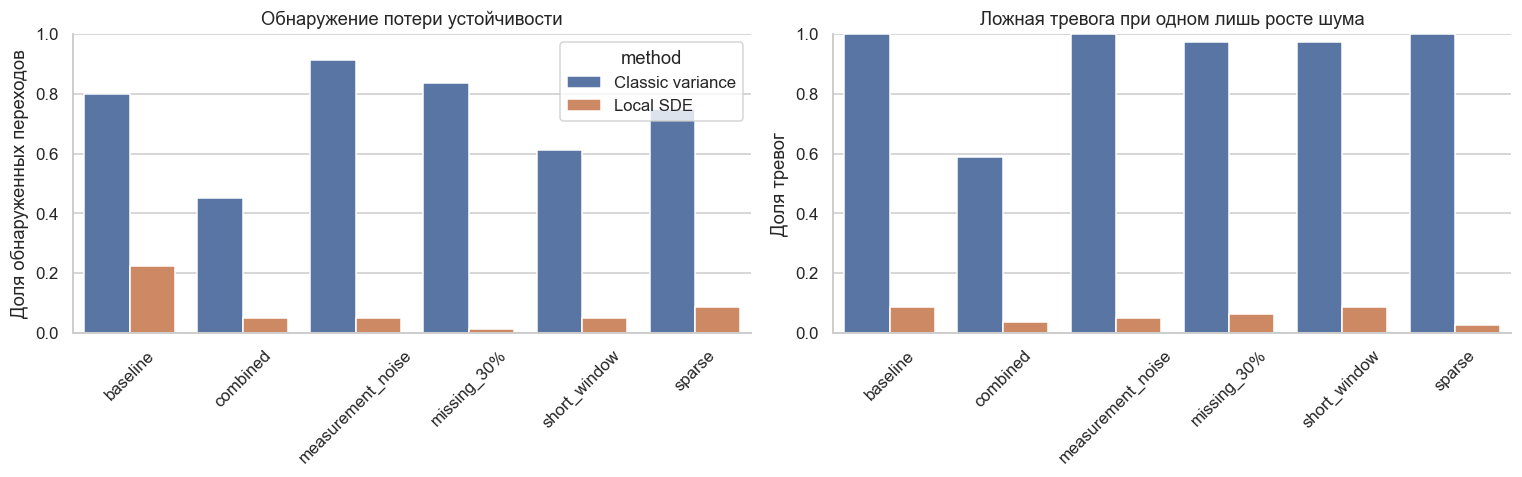

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sensitivity = summary.copy()
sns.barplot(
    sensitivity,
    x="condition", y="detection_stability_loss", hue="method", ax=axes[0],
)
axes[0].set_title("Обнаружение потери устойчивости")
axes[0].set_ylabel("Доля обнаруженных переходов")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    sensitivity,
    x="condition", y="false_alarm_noise_growth", hue="method", ax=axes[1],
)
axes[1].set_title("Ложная тревога при одном лишь росте шума")
axes[1].set_ylabel("Доля тревог")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)
axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

## 5. Вероятностное различение механизмов и калибровка

Задача формулируется как бинарная классификация: отличить `stability_loss` от
`noise_growth` при совпадающей теоретической дисперсии. Для каждого режима
траектории делятся на обучающую и тестовую выборки в отношении 70/30 без
пересечения траекторий.

Сначала каждый классический EWS проверяется отдельно, затем сравниваются две
многомерные базовые модели:

- **Classic EWS:** совместные изменения дисперсии, AR(1) и асимметрии;
- **Local SDE:** оцененные снижение $\kappa$ и рост $\sigma$.

Скорость восстановления монотонно связана с положительным AR(1), а коэффициент
вариации плохо определен около нулевого равновесия. Поэтому эти признаки
показаны отдельно и не дублируются в многомерной модели Classic EWS.

In [11]:
FEATURE_SETS = {
    "Variance only": ["variance_change"],
    "AR(1) only": ["ar1_change"],
    "Recovery rate only": ["recovery_rate_change"],
    "Coefficient variation only": ["log_cv_change"],
    "Skewness only": ["skewness_change"],
    "Classic EWS": ["variance_change", "ar1_change", "skewness_change"],
    "Local SDE": ["kappa_decline", "sigma_growth"],
}


def expected_calibration_error(y_true: np.ndarray, probability: np.ndarray, bins: int = 8) -> float:
    edges = np.linspace(0.0, 1.0, bins + 1)
    bin_id = np.clip(np.digitize(probability, edges) - 1, 0, bins - 1)
    error = 0.0
    for current_bin in range(bins):
        mask = bin_id == current_bin
        if mask.any():
            error += mask.mean() * abs(y_true[mask].mean() - probability[mask].mean())
    return float(error)


prediction_rows = []
metric_rows = []

for condition_name in CONDITIONS:
    data = monte_carlo.query(
        "condition == @condition_name and scenario in ['stability_loss', 'noise_growth']"
    ).copy()
    data["target"] = (data["scenario"] == "stability_loss").astype(int)

    split_rng = np.random.default_rng(SEED + sum(map(ord, condition_name)))
    test_repetitions = set(split_rng.choice(data["repetition"].unique(), size=36, replace=False))
    is_test = data["repetition"].isin(test_repetitions)

    for model_name, features in FEATURE_SETS.items():
        complete = data[features].notna().all(axis=1)
        train = data.loc[(~is_test) & complete]
        test = data.loc[is_test & complete]

        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, random_state=SEED),
        )
        model.fit(train[features], train["target"])
        probability = model.predict_proba(test[features])[:, 1]
        y_test = test["target"].to_numpy()

        metric_rows.append({
            "condition": condition_name,
            "model": model_name,
            "roc_auc": roc_auc_score(y_test, probability),
            "brier": brier_score_loss(y_test, probability),
            "ece": expected_calibration_error(y_test, probability),
            "n_test": len(test),
        })
        prediction_rows.extend(
            {
                "condition": condition_name,
                "model": model_name,
                "target": int(target),
                "probability": float(prob),
            }
            for target, prob in zip(y_test, probability)
        )

probability_metrics = pd.DataFrame(metric_rows)
predictions = pd.DataFrame(prediction_rows)

display(
    probability_metrics.pivot(
        index="condition", columns="model", values=["roc_auc", "brier", "ece"]
    ).style.format("{:.3f}")
)

Средний ROC-AUC равен 0,934 для Classic EWS и 0,950 для Local SDE. AUC следует читать вместе с оценкой Брайера и ошибкой калибровки: хорошее ранжирование не гарантирует точных вероятностей.

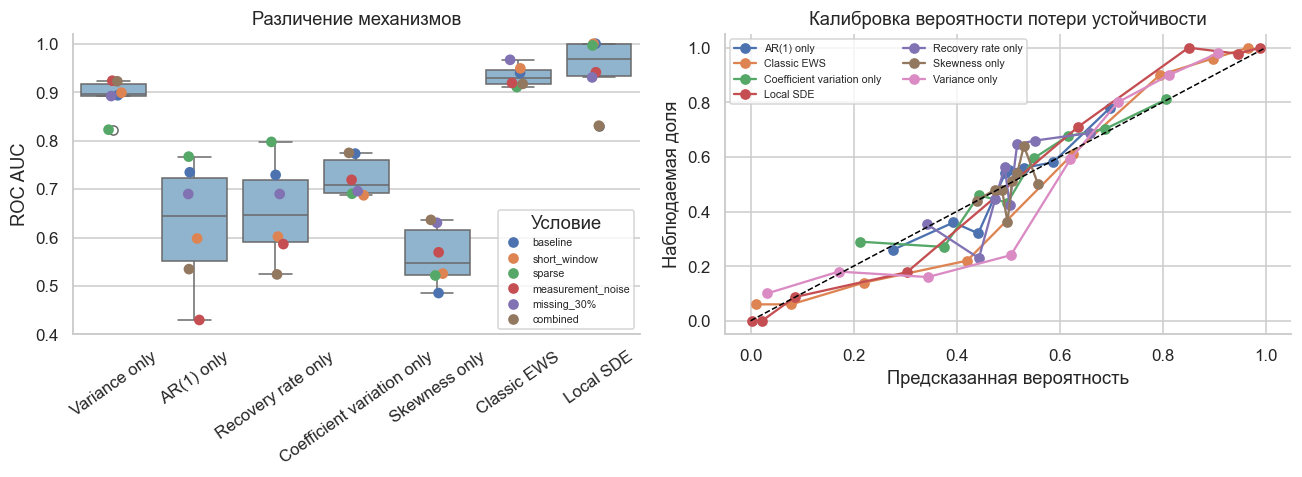

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(
    probability_metrics, x="model", y="roc_auc", ax=axes[0],
    color="#86b6d7",
)
sns.stripplot(
    probability_metrics, x="model", y="roc_auc", hue="condition",
    ax=axes[0], size=7,
)
axes[0].set_title("Различение механизмов")
axes[0].set_xlabel("")
axes[0].set_ylabel("ROC AUC")
axes[0].set_ylim(0.4, 1.02)
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="Условие", fontsize=7)

for model_name, group in predictions.groupby("model"):
    observed_fraction, predicted_mean = calibration_curve(
        group["target"], group["probability"], n_bins=8, strategy="quantile"
    )
    axes[1].plot(predicted_mean, observed_fraction, marker="o", label=model_name)
axes[1].plot([0, 1], [0, 1], ls="--", color="black", lw=1)
axes[1].set_title("Калибровка вероятности потери устойчивости")
axes[1].set_xlabel("Предсказанная вероятность")
axes[1].set_ylabel("Наблюдаемая доля")
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

## 6. Модель в пространстве состояний: OU-процесс и оценивание Калмана

Оценивание по моментам вычитает заранее известную дисперсию шума измерения.
Альтернативой служит локальная модель в пространстве состояний:

$$
X_{i+1}=\phi_iX_i+\eta_i,\quad
\phi_i=e^{-\kappa\Delta t_i},\quad
Y_i=X_i+\varepsilon_i,
$$

где $\eta_i$ - процессный шум, а $\varepsilon_i\sim N(0,\tau^2)$ - шум
измерения. Правдоподобие, вычисленное фильтром Калмана, допускает пропущенные
наблюдения и совместную оценку $\kappa$, $\sigma$ и $\tau$. Локальное равновесие
в каждом окне центрируется наблюдаемым средним, чтобы не добавлять четвертый
параметр в коротком окне.

Критерии успешности заданы до расчета результатов:

1. доля успешных оценок модели в пространстве состояний не ниже 90% во всех режимах;
2. ROC-AUC в базовом режиме не ниже 0,90;
3. средний ROC-AUC уступает оцениванию по моментам не более чем на 0,02.

In [13]:
KALMAN_BOUNDS = np.log([
    (0.02, 3.0),   # kappa
    (0.01, 2.0),   # process sigma
    (0.001, 1.0),  # measurement noise tau
])


def kalman_ou_negative_log_likelihood(
    log_parameters: np.ndarray,
    time: np.ndarray,
    values: np.ndarray,
) -> float:
    # Точное правдоподобие Калмана для нерегулярных шагов и NaN-наблюдений.
    kappa, process_sigma, measurement_noise = np.exp(log_parameters)
    centered = values - np.nanmean(values)
    stationary_variance = process_sigma**2 / (2.0 * kappa)

    filtered_mean = 0.0
    filtered_variance = stationary_variance
    negative_log_likelihood = 0.0
    n_observed = 0

    for i in range(len(time)):
        if i > 0:
            dt = time[i] - time[i - 1]
            phi = np.exp(-kappa * dt)
            innovation_variance = stationary_variance * (1.0 - phi**2)
            filtered_mean = phi * filtered_mean
            filtered_variance = phi**2 * filtered_variance + innovation_variance

        if np.isfinite(centered[i]):
            prediction_variance = filtered_variance + measurement_noise**2
            residual = centered[i] - filtered_mean
            negative_log_likelihood += 0.5 * (
                np.log(2.0 * np.pi * prediction_variance)
                + residual**2 / prediction_variance
            )
            kalman_gain = filtered_variance / prediction_variance
            filtered_mean += kalman_gain * residual
            filtered_variance = max(
                (1.0 - kalman_gain) * filtered_variance,
                1e-12,
            )
            n_observed += 1

    return negative_log_likelihood if n_observed >= 8 else 1e12


def fit_local_ou_kalman(time: np.ndarray, values: np.ndarray) -> Dict[str, float]:
    # Два разумных старта уменьшают риск локального оптимума.
    finite = np.isfinite(values)
    observed_values = values[finite]
    empty = {
        "kappa_hat": np.nan,
        "sigma_hat": np.nan,
        "measurement_noise_hat": np.nan,
        "converged": False,
        "n_observed": int(finite.sum()),
    }
    if finite.sum() < 8:
        return empty

    dt = float(np.median(np.diff(time)))
    observed_variance = float(np.var(observed_values, ddof=1))
    differences = np.diff(values)
    differences = differences[np.isfinite(differences)]
    tau_initial = max(
        float(np.std(differences) / 4.0) if len(differences) else 0.03,
        0.005,
    )
    latent_variance = max(observed_variance - tau_initial**2, 1e-4)

    centered = values - np.nanmean(values)
    adjacent = finite[:-1] & finite[1:]
    lag_covariance = (
        float(np.mean(centered[:-1][adjacent] * centered[1:][adjacent]))
        if adjacent.sum() > 4 else 0.5 * observed_variance
    )
    phi_initial = np.clip(
        lag_covariance / max(observed_variance, 1e-8), 0.10, 0.98
    )
    kappa_initial = np.clip(-np.log(phi_initial) / dt, 0.03, 2.5)
    sigma_initial = np.clip(
        np.sqrt(2.0 * kappa_initial * latent_variance), 0.02, 1.5
    )

    starts = [
        np.log([kappa_initial, sigma_initial, tau_initial]),
        np.log([0.5, np.sqrt(max(observed_variance, 1e-4)), max(0.03, tau_initial)]),
    ]
    candidates = [
        minimize(
            kalman_ou_negative_log_likelihood,
            start,
            args=(time, values),
            method="L-BFGS-B",
            bounds=KALMAN_BOUNDS,
            options={"maxiter": 120},
        )
        for start in starts
    ]
    result = min(candidates, key=lambda candidate: candidate.fun)
    kappa_hat, sigma_hat, measurement_noise_hat = np.exp(result.x)
    converged = bool(result.success and np.isfinite(result.fun))

    return {
        "kappa_hat": float(kappa_hat),
        "sigma_hat": float(sigma_hat),
        "measurement_noise_hat": float(measurement_noise_hat),
        "converged": converged,
        "n_observed": int(finite.sum()),
    }


def fit_kalman_window(
    observed: pd.DataFrame,
    cfg: ExperimentConfig,
    window_end: float,
) -> Dict[str, float]:
    mask = (
        (observed["time"] > window_end - cfg.window_width)
        & (observed["time"] <= window_end)
    )
    frame = observed.loc[mask]
    return fit_local_ou_kalman(
        frame["time"].to_numpy(), frame["value"].to_numpy()
    )

In [14]:
def run_kalman_benchmark(
    conditions: Dict[str, ExperimentConfig],
    n_repetitions: int = 60,
    seed: int = SEED + 10,
) -> pd.DataFrame:
    random_state = np.random.default_rng(seed)
    rows = []

    for condition_name, cfg in conditions.items():
        for scenario in ["stability_loss", "noise_growth"]:
            for repetition in range(n_repetitions):
                observed = simulate_observations(scenario, cfg, random_state)
                early = fit_kalman_window(observed, cfg, 25.0)
                late = fit_kalman_window(observed, cfg, 78.0)

                moment_early = estimate_local_dynamics(
                    observed["time"].to_numpy(), observed["value"].to_numpy(),
                    25.0, cfg.window_width, cfg.measurement_noise_sd,
                )
                moment_late = estimate_local_dynamics(
                    observed["time"].to_numpy(), observed["value"].to_numpy(),
                    78.0, cfg.window_width, cfg.measurement_noise_sd,
                )

                late_mask = (
                    (observed["time"] > 78.0 - cfg.window_width)
                    & (observed["time"] <= 78.0)
                )
                rows.append({
                    "condition": condition_name,
                    "scenario": scenario,
                    "repetition": repetition,
                    "kalman_converged": early["converged"] and late["converged"],
                    "kalman_kappa_decline": early["kappa_hat"] - late["kappa_hat"],
                    "kalman_sigma_growth": late["sigma_hat"] - early["sigma_hat"],
                    "kalman_tau_change": (
                        late["measurement_noise_hat"] - early["measurement_noise_hat"]
                    ),
                    "kalman_kappa_late": late["kappa_hat"],
                    "kalman_sigma_late": late["sigma_hat"],
                    "kalman_tau_late": late["measurement_noise_hat"],
                    "moment_kappa_decline": (
                        moment_early["kappa_hat"] - moment_late["kappa_hat"]
                    ),
                    "moment_sigma_growth": (
                        moment_late["sigma_hat"] - moment_early["sigma_hat"]
                    ),
                    "moment_kappa_late": moment_late["kappa_hat"],
                    "moment_sigma_late": moment_late["sigma_hat"],
                    "kappa_true_late": observed.loc[late_mask, "kappa_true"].mean(),
                    "sigma_true_late": observed.loc[late_mask, "sigma_true"].mean(),
                    "tau_true": cfg.measurement_noise_sd,
                })
    return pd.DataFrame(rows)


kalman_benchmark = run_kalman_benchmark(CONDITIONS)

coverage_rows = []
auc_rows = []
prediction_rows_kalman = []
feature_sets_kalman = {
    "Moment SDE": ["moment_kappa_decline", "moment_sigma_growth"],
    "Kalman SDE": [
        "kalman_kappa_decline", "kalman_sigma_growth", "kalman_tau_change"
    ],
}

for condition_name, group in kalman_benchmark.groupby("condition"):
    coverage_rows.append({
        "condition": condition_name,
        "method": "Kalman SDE",
        "coverage": group["kalman_converged"].mean(),
    })
    coverage_rows.append({
        "condition": condition_name,
        "method": "Moment SDE",
        "coverage": group[["moment_kappa_decline", "moment_sigma_growth"]]
        .notna().all(axis=1).mean(),
    })

    split_rng = np.random.default_rng(SEED + 100 + sum(map(ord, condition_name)))
    test_repetitions = set(
        split_rng.choice(group["repetition"].unique(), size=18, replace=False)
    )
    is_test = group["repetition"].isin(test_repetitions)

    for method, features in feature_sets_kalman.items():
        complete = group[features].notna().all(axis=1)
        train = group.loc[(~is_test) & complete]
        test = group.loc[is_test & complete]
        target_train = (train["scenario"] == "stability_loss").astype(int)
        target_test = (test["scenario"] == "stability_loss").astype(int)

        classifier = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, random_state=SEED),
        )
        classifier.fit(train[features], target_train)
        probability = classifier.predict_proba(test[features])[:, 1]
        auc_rows.append({
            "condition": condition_name,
            "method": method,
            "roc_auc": roc_auc_score(target_test, probability),
            "n_test": len(test),
        })

coverage_kalman = pd.DataFrame(coverage_rows)
auc_kalman = pd.DataFrame(auc_rows)

#### Доля успешных локальных оценок

In [15]:
display(
    coverage_kalman.pivot(index="condition", columns="method", values="coverage")
    .style.format("{:.1%}")
)

method,Kalman SDE,Moment SDE
condition,,
baseline,100.0%,100.0%
combined,100.0%,33.3%
measurement_noise,100.0%,86.7%
missing_30%,100.0%,91.7%
short_window,100.0%,100.0%
sparse,100.0%,90.8%


#### ROC-AUC на отложенных траекториях

In [16]:
display(
    auc_kalman.pivot(index="condition", columns="method", values="roc_auc")
    .style.format("{:.3f}")
)

method,Kalman SDE,Moment SDE
condition,,
baseline,1.000,1.000
combined,0.898,0.893
measurement_noise,1.000,0.937
missing_30%,1.000,0.945
short_window,1.000,1.000
sparse,0.975,0.992


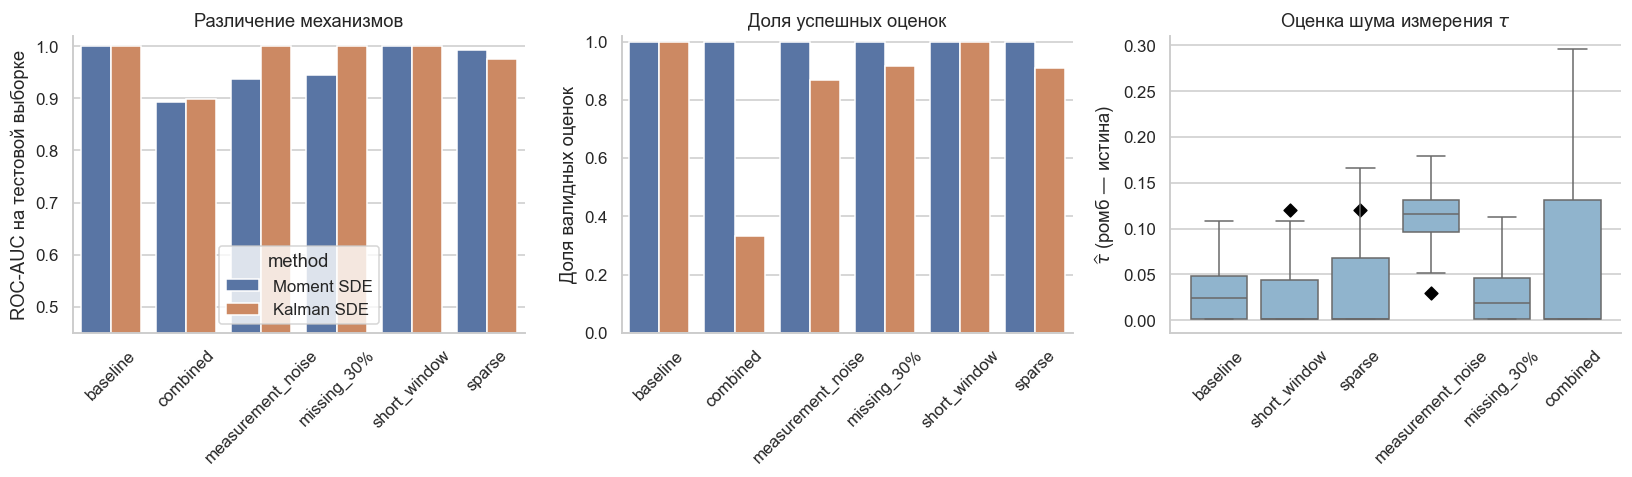

In [17]:
parameter_accuracy = []
for condition_name, group in kalman_benchmark.groupby("condition"):
    for method_prefix, method_label in [
        ("moment", "Moment SDE"), ("kalman", "Kalman SDE")
    ]:
        kappa_error = group[f"{method_prefix}_kappa_late"] - group["kappa_true_late"]
        sigma_error = group[f"{method_prefix}_sigma_late"] - group["sigma_true_late"]
        parameter_accuracy.append({
            "condition": condition_name,
            "method": method_label,
            "kappa_rmse": np.sqrt(np.nanmean(kappa_error**2)),
            "sigma_rmse": np.sqrt(np.nanmean(sigma_error**2)),
        })
parameter_accuracy = pd.DataFrame(parameter_accuracy)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.barplot(auc_kalman, x="condition", y="roc_auc", hue="method", ax=axes[0])
axes[0].set_title("Различение механизмов")
axes[0].set_ylabel("ROC-AUC на тестовой выборке")
axes[0].set_ylim(0.45, 1.02)

sns.barplot(coverage_kalman, x="condition", y="coverage", hue="method", ax=axes[1])
axes[1].set_title("Доля успешных оценок")
axes[1].set_ylabel("Доля валидных оценок")
axes[1].set_ylim(0, 1.02)
axes[1].get_legend().remove()

sns.boxplot(
    kalman_benchmark, x="condition", y="kalman_tau_late", ax=axes[2],
    showfliers=False, color="#86b6d7",
)
true_tau = kalman_benchmark.groupby("condition")["tau_true"].first()
for index, condition_name in enumerate(true_tau.index):
    axes[2].scatter(index, true_tau[condition_name], marker="D", color="black", s=35)
axes[2].set_title(r"Оценка шума измерения $\tau$")
axes[2].set_ylabel(r"$\widehat\tau$ (ромб — истина)")

for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

#### RMSE локальных параметров в позднем окне

In [18]:
display(
    parameter_accuracy.pivot(
        index="condition", columns="method", values=["kappa_rmse", "sigma_rmse"]
    ).style.format("{:.3f}")
)

In [19]:
minimum_kalman_coverage = coverage_kalman.query("method == 'Kalman SDE'")["coverage"].min()
baseline_kalman_auc = auc_kalman.query(
    "condition == 'baseline' and method == 'Kalman SDE'"
)["roc_auc"].iloc[0]
mean_auc_by_method = auc_kalman.groupby("method")["roc_auc"].mean()
auc_non_degradation = (
    mean_auc_by_method["Kalman SDE"]
    >= mean_auc_by_method["Moment SDE"] - 0.02
)


gate_table = pd.DataFrame({
    "Проверка": [
        "Минимальная доля успешных оценок >= 90%",
        "ROC-AUC в базовом режиме >= 0,90",
        "Средний AUC уступает Moment OU не более чем на 0,02",
    ],
    "Значение": [
        f"{minimum_kalman_coverage:.1%}",
        f"{baseline_kalman_auc:.3f}",
        (
            f"Kalman {mean_auc_by_method['Kalman SDE']:.3f}; "
            f"moment {mean_auc_by_method['Moment SDE']:.3f}"
        ),
    ],
    "Пройдено": [
        minimum_kalman_coverage >= 0.90,
        baseline_kalman_auc >= 0.90,
        auc_non_degradation,
    ],
})
display(gate_table)

,Проверка,Значение,Пройдено
0,Минимальная доля успешных оценок >= 90%,100.0%,True
1,"ROC-AUC в базовом режиме >= 0,90",1.000,True
2,Средний AUC уступает Moment OU не более чем на...,Kalman 0.979; moment 0.961,True


**Заданные критерии выполнены.**

Kalman OU сохраняет оценку при редких наблюдениях и пропусках лучше метода моментов. Это подтверждает пригодность оценивателя для следующего этапа, но не доказывает адекватность OU-модели эпидемиологическим данным.

## 7. Расширенное сравнение методов идентификации СДУ

Все локальные методы решают одну задачу на одинаковых окнах: оценивают снос и
диффузию и различают `stability_loss` и `noise_growth`.

- **Moment OU** - быстрая AR(1)-оценка локальных $\kappa$ и $\sigma$;
- **Kalman OU** - правдоподобие модели в пространстве состояний с отдельным
  шумом измерения;
- **SINDy-STLSQ** - разреженная оценка кубического сноса
  $f(x)=\xi_0+\xi_1x+\xi_2x^2+\xi_3x^3$ и диффузии по инновациям;
- **Bayesian SINDy (spike-and-slab)** - точное апостериорное усреднение восьми
  вариантов включения $x,x^2,x^3$ и интервалы неопределенности;
- **Neural SDE (Euler)** - снос и зависящая от состояния диффузия задаются
  нейронными сетями, наблюдаемое значение считается состоянием;
- **Latent Neural SDE (VI)** - вводится скрытая траектория, нейросетевые снос и
  диффузия и отдельная гауссовская модель наблюдений
  $y_t\mid z_t\sim N(z_t,\tau^2)$.

Априорное распределение spike-and-slab переносит неопределенность выбора членов
библиотеки в апостериорные интервалы. Neural SDE со скрытым состоянием проверяет
эффект явного разделения процессного шума и шума измерения.

Итоговый классификатор обучается на траекториях 0-23; траектории 24-35 остаются
отложенными. Порог равен 95-му перцентилю максимальной вероятности на каждой
стационарной обучающей траектории. Помимо ROC-AUC приводятся RMSE параметров,
доля успешных оценок, покрытие интервалов, пропуски переходов, ложные тревоги и
медианное упреждение.

### 7.1. Восстановление параметров и покрытие интервалов

Сравниваются ошибки локальных оценок $\kappa$ и $\sigma$, доля успешных оценок и эмпирическое покрытие интервалов Bayesian SINDy.

In [20]:
import importlib.util
from sklearn.metrics import roc_auc_score


def load_sde_helper():
    """Import the optional heavy estimators from either notebook working directory."""
    candidates = [
        Path("src/sde_early_warning/estimators.py"),
        Path("../src/sde_early_warning/estimators.py"),
        Path("sde_benchmarks.py"),
        Path("outputs/sde_benchmarks.py"),
    ]
    helper_path = next((path for path in candidates if path.exists()), None)
    if helper_path is None:
        raise FileNotFoundError("Не найден модуль estimators.py")
    spec = importlib.util.spec_from_file_location("sde_benchmarks", helper_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


def resolve_benchmark_file(filename):
    candidates = [
        Path("data") / filename,
        Path("../data") / filename,
        Path("outputs/data") / filename,
    ]
    path = next((candidate for candidate in candidates if candidate.exists()), None)
    if path is None:
        raise FileNotFoundError(f"Не найден файл результатов сравнительного эксперимента: {filename}")
    return path


sde_helper = load_sde_helper()
extended_sde = pd.read_csv(resolve_benchmark_file("extended_sde_benchmark.csv"))
extended_sequence = pd.read_csv(resolve_benchmark_file("extended_sde_sequential.csv"))
extended_sde["usable"] = (
    extended_sde["converged"]
    & extended_sde[["kappa_decline", "sigma_growth"]].notna().all(axis=1)
)

extended_coverage = (
    extended_sde.groupby(["condition", "method"])["usable"]
    .mean().rename("coverage").reset_index()
)
parameter_test = extended_sde.query(
    "repetition >= 24 and scenario != 'stationary' and usable"
).copy()
parameter_test["kappa_squared_error"] = (
    parameter_test["kappa_late"] - parameter_test["kappa_true_late"]
) ** 2
parameter_test["sigma_squared_error"] = (
    parameter_test["sigma_late"] - parameter_test["sigma_true_late"]
) ** 2
parameter_test["tau_squared_error"] = (
    parameter_test["tau_late"] - parameter_test["tau_true"]
) ** 2
extended_parameter_metrics = (
    parameter_test.groupby(["condition", "method"])
    .agg(
        kappa_RMSE=("kappa_squared_error", lambda values: np.sqrt(values.mean())),
        sigma_RMSE=("sigma_squared_error", lambda values: np.sqrt(values.mean())),
        tau_RMSE=("tau_squared_error", lambda values: np.sqrt(values.mean()) if values.notna().any() else np.nan),
        n_test=("repetition", "size"),
    ).reset_index()
)

bayesian_interval_test = parameter_test.query(
    "method == 'Bayesian SINDy (spike-slab)'"
).dropna(subset=["kappa_lower_late", "kappa_upper_late"]).copy()
bayesian_interval_test["covered_95"] = (
    (bayesian_interval_test["kappa_true_late"] >= bayesian_interval_test["kappa_lower_late"])
    & (bayesian_interval_test["kappa_true_late"] <= bayesian_interval_test["kappa_upper_late"])
)
bayesian_interval_test["interval_width"] = (
    bayesian_interval_test["kappa_upper_late"] - bayesian_interval_test["kappa_lower_late"]
)
bayesian_interval_metrics = (
    bayesian_interval_test.groupby("condition")
    .agg(
        empirical_coverage_95=("covered_95", "mean"),
        median_interval_width=("interval_width", "median"),
        n_intervals=("covered_95", "size"),
    ).reset_index()
)

### 7.2. Различение механизмов и последовательная тревога

Для каждого метода используется один и тот же логистический классификатор. Порог калибруется по максимумам на стационарных обучающих траекториях.

In [21]:
# Для всех оценивателей используется один итоговый классификатор. Реплики
# 0:23 образуют обучающую выборку, 24:35 остаются отложенными. Порог 95-го
# перцентиля калибруется только на стационарных обучающих траекториях.
extended_classifiers = {}
extended_thresholds = {}
discrimination_rows = []
for (condition, method), block in extended_sde.groupby(["condition", "method"]):
    features = ["kappa_decline", "sigma_growth"]
    training = block.query(
        "repetition < 24 and scenario in ['stability_loss', 'noise_growth'] and usable"
    )
    testing = block.query(
        "repetition >= 24 and scenario in ['stability_loss', 'noise_growth'] and usable"
    )
    if training["scenario"].nunique() < 2 or testing["scenario"].nunique() < 2:
        discrimination_rows.append({
            "condition": condition, "method": method, "ROC-AUC": np.nan,
            "test_coverage": len(testing) / 24, "n_test": len(testing),
        })
        continue
    classifier = make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED)
    )
    classifier.fit(
        training[features],
        (training["scenario"] == "stability_loss").astype(int),
    )
    probability = classifier.predict_proba(testing[features])[:, 1]
    extended_classifiers[(condition, method)] = classifier
    discrimination_rows.append({
        "condition": condition,
        "method": method,
        "ROC-AUC": roc_auc_score(
            (testing["scenario"] == "stability_loss").astype(int), probability
        ),
        "test_coverage": len(testing) / 24,
        "n_test": len(testing),
    })

extended_discrimination = pd.DataFrame(discrimination_rows)

sequence_scored_parts = []
for (condition, method), block in extended_sequence.groupby(["condition", "method"]):
    key = (condition, method)
    if key not in extended_classifiers:
        continue
    usable = block["converged"] & block[["kappa_decline", "sigma_growth"]].notna().all(axis=1)
    scored = block.loc[usable].copy()
    scored["probability_stability_loss"] = extended_classifiers[key].predict_proba(
        scored[["kappa_decline", "sigma_growth"]]
    )[:, 1]
    sequence_scored_parts.append(scored)
sequence_scored = pd.concat(sequence_scored_parts, ignore_index=True)

# Последовательный порог основан на максимуме вероятности вдоль каждой
# стационарной обучающей траектории и учитывает многократные проверки.
for (condition, method), block in sequence_scored.query(
    "scenario == 'stationary' and repetition < 24"
).groupby(["condition", "method"]):
    path_maxima = block.groupby("repetition")["probability_stability_loss"].max()
    extended_thresholds[(condition, method)] = float(np.quantile(path_maxima, 0.95))

alarm_parts = []
for (condition, method), block in sequence_scored.groupby(["condition", "method"]):
    scored = block.copy()
    scored["alarm"] = (
        scored["probability_stability_loss"] > extended_thresholds[(condition, method)]
    )
    alarm_parts.append(scored)
sequence_scored = pd.concat(alarm_parts, ignore_index=True)

alarm_rows = []
for keys, block in sequence_scored.groupby(["condition", "method", "scenario"]):
    condition, method, scenario = keys
    alarm_times = []
    covered = []
    for repetition in range(24, 36):
        path = block.query("repetition == @repetition").sort_values("window_end")
        covered.append(len(path) >= 2)
        crossing = path.loc[path["alarm"], "window_end"]
        alarm_times.append(float(crossing.iloc[0]) if len(crossing) else np.nan)
    alarm_times = np.asarray(alarm_times)
    detected = np.isfinite(alarm_times)
    alarm_rows.append({
        "condition": condition,
        "method": method,
        "scenario": scenario,
        "alarm_rate": detected.mean(),
        "miss_rate": 1 - detected.mean(),
        "path_coverage": np.mean(covered),
        "median_lead_time": (
            BASE_CONFIG.transition_time - np.nanmedian(alarm_times)
            if detected.any() else np.nan
        ),
    })
extended_alarm_long = pd.DataFrame(alarm_rows)
extended_alarm = (
    extended_alarm_long.pivot_table(
        index=["condition", "method"], columns="scenario", values="alarm_rate"
    )
    .rename(columns={
        "stationary": "false_alarm_stationary",
        "noise_growth": "false_alarm_noise_growth",
        "stability_loss": "detection_stability_loss",
    })
    .join(
        extended_alarm_long.query("scenario == 'stability_loss'")
        .set_index(["condition", "method"])[["miss_rate", "path_coverage", "median_lead_time"]]
    ).reset_index()
)

### 7.3. Сводные таблицы и пример восстановленного сноса

Параметрическая точность, различение механизмов, доля успешных оценок и метрики тревог рассматриваются совместно.

#### Доля успешных оценок и точность параметров

In [22]:
display(
    extended_coverage.merge(extended_parameter_metrics, on=["condition", "method"], how="left")
    .sort_values(["condition", "kappa_RMSE"])
    .style.format({"coverage": "{:.1%}", "kappa_RMSE": "{:.3f}", "sigma_RMSE": "{:.3f}", "tau_RMSE": "{:.3f}", "n_test": "{:.0f}"})
)

,condition,method,coverage,kappa_RMSE,sigma_RMSE,tau_RMSE,n_test
0,baseline,Bayesian SINDy (spike-slab),100.0%,0.414,0.036,nan,24
1,baseline,Kalman OU,100.0%,0.544,0.043,0.031,24
3,baseline,Moment OU,100.0%,0.569,0.045,nan,24
5,baseline,SINDy-STLSQ,100.0%,0.755,0.039,nan,24
2,baseline,Latent Neural SDE (VI),100.0%,0.863,0.049,0.010,24
4,baseline,Neural SDE (Euler),100.0%,0.868,0.049,nan,24
6,combined,Bayesian SINDy (spike-slab),53.7%,0.552,0.119,nan,12
8,combined,Latent Neural SDE (VI),100.0%,0.644,0.151,0.082,24
7,combined,Kalman OU,100.0%,0.683,0.152,0.110,24
11,combined,SINDy-STLSQ,53.7%,0.823,0.125,nan,12


#### Калибровка интервалов Bayesian SINDy

In [23]:
display(
    bayesian_interval_metrics.style.format({
        "empirical_coverage_95": "{:.1%}",
        "median_interval_width": "{:.3f}",
        "n_intervals": "{:.0f}",
    })
)

,condition,empirical_coverage_95,median_interval_width,n_intervals
0,baseline,100.0%,1.450,24
1,combined,91.7%,1.056,12


#### Различение потери устойчивости и роста шума

In [24]:
display(
    extended_discrimination.sort_values(["condition", "ROC-AUC"], ascending=[True, False])
    .style.format({"ROC-AUC": "{:.3f}", "test_coverage": "{:.1%}", "n_test": "{:.0f}"})
)

,condition,method,ROC-AUC,test_coverage,n_test
0,baseline,Bayesian SINDy (spike-slab),1.000,100.0%,24
1,baseline,Kalman OU,1.000,100.0%,24
2,baseline,Latent Neural SDE (VI),1.000,100.0%,24
3,baseline,Moment OU,1.000,100.0%,24
4,baseline,Neural SDE (Euler),1.000,100.0%,24
5,baseline,SINDy-STLSQ,1.000,100.0%,24
9,combined,Moment OU,0.920,41.7%,10
11,combined,SINDy-STLSQ,0.829,50.0%,12
7,combined,Kalman OU,0.826,100.0%,24
8,combined,Latent Neural SDE (VI),0.653,100.0%,24


#### Последовательные тревоги

,condition,method,false_alarm_noise_growth,detection_stability_loss,false_alarm_stationary,miss_rate,path_coverage,median_lead_time
0,baseline,Bayesian SINDy (spike-slab),0.0%,16.7%,0.0%,83.3%,100.0%,26.0
5,baseline,SINDy-STLSQ,0.0%,16.7%,8.3%,83.3%,100.0%,26.0
2,baseline,Latent Neural SDE (VI),0.0%,8.3%,8.3%,91.7%,100.0%,2.0
3,baseline,Moment OU,0.0%,8.3%,0.0%,91.7%,100.0%,18.0
4,baseline,Neural SDE (Euler),0.0%,8.3%,8.3%,91.7%,100.0%,2.0
1,baseline,Kalman OU,0.0%,0.0%,0.0%,100.0%,100.0%,nan
11,combined,SINDy-STLSQ,16.7%,16.7%,8.3%,83.3%,75.0%,6.0
6,combined,Bayesian SINDy (spike-slab),0.0%,0.0%,8.3%,100.0%,75.0%,nan
7,combined,Kalman OU,0.0%,0.0%,0.0%,100.0%,100.0%,nan
8,combined,Latent Neural SDE (VI),8.3%,0.0%,0.0%,100.0%,100.0%,nan


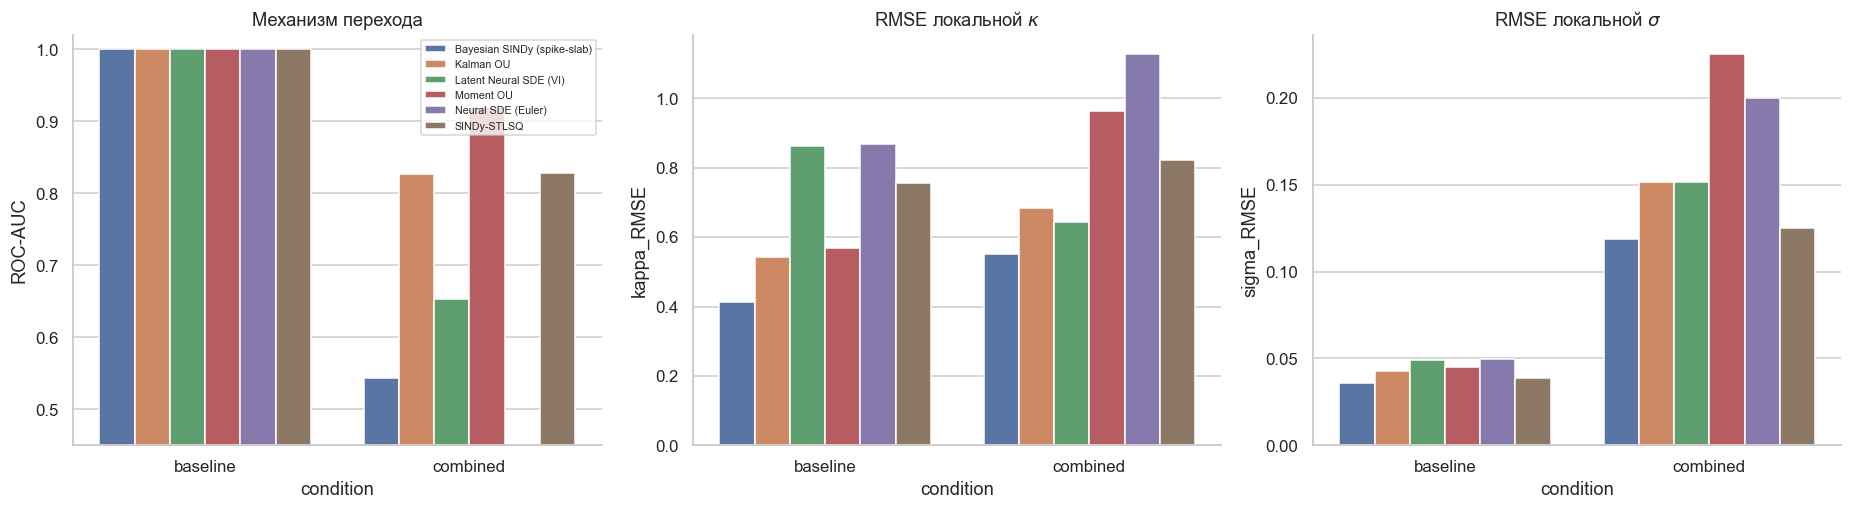

In [25]:
display(
    extended_alarm.sort_values(["condition", "detection_stability_loss"], ascending=[True, False])
    .style.format({
        "false_alarm_stationary": "{:.1%}", "false_alarm_noise_growth": "{:.1%}",
        "detection_stability_loss": "{:.1%}", "miss_rate": "{:.1%}",
        "path_coverage": "{:.1%}", "median_lead_time": "{:.1f}",
    })
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
sns.barplot(extended_discrimination, x="condition", y="ROC-AUC", hue="method", ax=axes[0])
axes[0].set_ylim(0.45, 1.02)
axes[0].set_title("Механизм перехода")
sns.barplot(extended_parameter_metrics, x="condition", y="kappa_RMSE", hue="method", ax=axes[1])
axes[1].set_title(r"RMSE локальной $\kappa$")
sns.barplot(extended_parameter_metrics, x="condition", y="sigma_RMSE", hue="method", ax=axes[2])
axes[2].set_title(r"RMSE локальной $\sigma$")
for ax in axes[1:]:
    ax.get_legend().remove()
axes[0].legend(fontsize=7, title="")
plt.tight_layout()
plt.show()

# One transparent example of what the discovery methods actually recover.
equation_rng = np.random.default_rng(SEED + 991)
equation_path = simulate_observations("stability_loss", BASE_CONFIG, equation_rng)
equation_window = equation_path.query("time > 62 and time <= 78")
equation_models = sde_helper.fit_discovery_estimators(
    equation_window["time"].to_numpy(), equation_window["value"].to_numpy(), neural_seed=991
)
equation_table = pd.DataFrame([
    {
        "method": method,
        "локальный снос": result["equation"],
        "kappa_hat": result["kappa_hat"],
        "sigma_hat": result["sigma_hat"],
        "tau_hat": result.get("tau_hat", np.nan),
        "active_terms": result["active_terms"],
    }
    for method, result in equation_models.items()
])

#### Пример восстановленного сноса

In [26]:
display(equation_table.style.format({"kappa_hat": "{:.3f}", "sigma_hat": "{:.3f}", "tau_hat": "{:.3f}", "active_terms": "{:.0f}"}))

neural_comparison = (
    extended_parameter_metrics[
        extended_parameter_metrics["method"].isin(["Neural SDE (Euler)", "Latent Neural SDE (VI)"])
    ]
    .merge(
        extended_discrimination,
        on=["condition", "method"],
        how="left",
    )
)

,method,локальный снос,kappa_hat,sigma_hat,tau_hat,active_terms
0,SINDy-STLSQ,-0.0591 + -0.958x + -0.191x² + +0.083x³,0.933,0.184,nan,4
1,Bayesian SINDy (spike-slab),-0.2101,0.070,0.187,nan,1
2,Neural SDE (Euler),"fθ(x), gθ(x)",0.806,0.167,nan,nan
3,Latent Neural SDE (VI),"z: dz=fθ(z)dt+gθ(z)dW; y|z~N(z,τ²)",0.696,0.159,0.017,nan


#### Neural SDE с наблюдаемым и скрытым состоянием

In [27]:
display(neural_comparison.style.format({
    "kappa_RMSE": "{:.3f}", "sigma_RMSE": "{:.3f}", "tau_RMSE": "{:.3f}",
    "ROC-AUC": "{:.3f}", "test_coverage": "{:.1%}", "n_test_x": "{:.0f}", "n_test_y": "{:.0f}",
}))

,condition,method,kappa_RMSE,sigma_RMSE,tau_RMSE,n_test_x,ROC-AUC,test_coverage,n_test_y
0,baseline,Latent Neural SDE (VI),0.863,0.049,0.010,24,1.000,100.0%,24
1,baseline,Neural SDE (Euler),0.868,0.049,nan,24,1.000,100.0%,24
2,combined,Latent Neural SDE (VI),0.644,0.151,0.082,24,0.653,100.0%,24
3,combined,Neural SDE (Euler),1.126,0.200,nan,12,0.400,50.0%,12


Методы сравниваются одновременно по ROC-AUC, ошибке параметров, покрытию интервалов, тревогам и доле успешных оценок. Ни одна из этих метрик по отдельности не определяет лучший метод.

## 8. Нелинейные переходы и диффузия, зависящая от состояния

Линейный OU-процесс используется как контрольная задача. Затем проверяются три
канонические нормальные формы: седло-узел $f=r-x^2$, транскритическая
$f=rx-x^2$ и бистабильная система $f=r+x-x^3$. Управляющий параметр выбран так,
чтобы истинная скорость восстановления проходила одинаковую траекторию
$0.8\to0.1$. Модели получают одинаковую степень приближения к потере
устойчивости при разной форме сноса.

Во всех трех системах диффузия зависит от состояния:
$g(x,t)=\sigma(t)[1+0.3\tanh(x-x^*(t))]$. Сценарий `noise_growth` сохраняет снос
и повышает $\sigma(t)$ так, чтобы локально-линейная дисперсия совпадала со
сценарием `stability_loss`. Используются одинаковые горизонты 25 и 78, окна
длины 16 и один набор моделей.

### 8.1. Геометрия нормальных форм и проверка симулятора

На графиках показаны движущееся устойчивое равновесие и изменение сноса. Частота обрезки траектории у границ симулятора вынесена в отдельную таблицу.

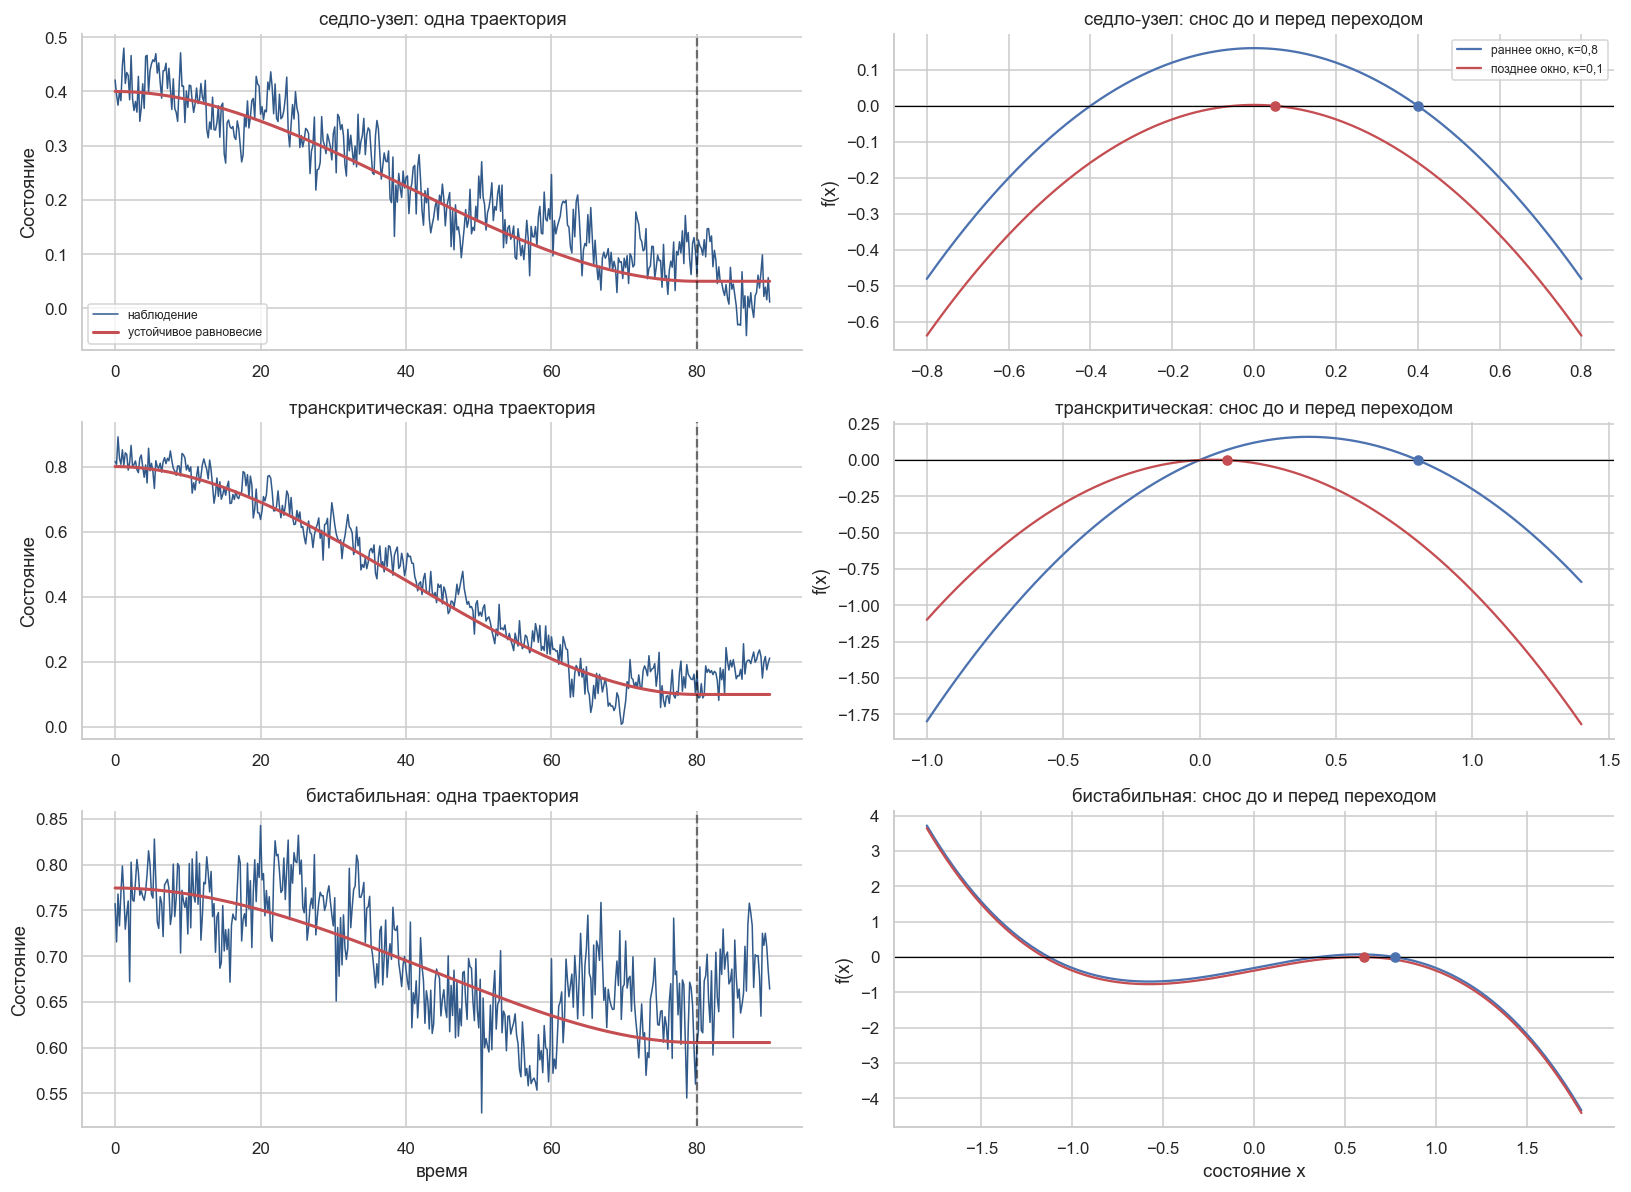

In [28]:
import sys


def load_local_module(module_name, filenames):
    path = next((Path(name) for name in filenames if Path(name).exists()), None)
    if path is None:
        raise FileNotFoundError(f"Не найден модуль {module_name}: {filenames}")
    spec = importlib.util.spec_from_file_location(module_name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


nonlinear_systems = load_local_module(
    "nonlinear_sde_systems",
    [
        "src/sde_early_warning/systems.py",
        "../src/sde_early_warning/systems.py",
        "nonlinear_sde_systems.py",
        "outputs/nonlinear_sde_systems.py",
    ],
)
nonlinear = pd.read_csv(resolve_benchmark_file("nonlinear_sde_benchmark.csv"))
nonlinear_sequence = pd.read_csv(resolve_benchmark_file("nonlinear_sde_sequential.csv"))
nonlinear["usable"] = (
    nonlinear["converged"]
    & nonlinear[["kappa_decline", "sigma_growth"]].notna().all(axis=1)
)

# --- Geometry and example paths -------------------------------------------------
system_labels = {
    "saddle_node": "седло-узел",
    "transcritical": "транскритическая",
    "bistable": "бистабильная",
}
figure_rng = np.random.default_rng(SEED + 4400)
fig, axes = plt.subplots(3, 2, figsize=(15, 11))
for row, system in enumerate(nonlinear_systems.SYSTEMS):
    example = nonlinear_systems.simulate_observations(
        system,
        "stability_loss",
        nonlinear_systems.BASE_NONLINEAR_CONFIG,
        figure_rng,
    )
    axes[row, 0].plot(example["time"], example["value"], lw=1.0, color="#315a8a", label="наблюдение")
    axes[row, 0].plot(example["time"], example["equilibrium"], lw=2.0, color="#c44e52", label="устойчивое равновесие")
    axes[row, 0].axvline(80, ls="--", color="black", alpha=.5)
    axes[row, 0].set_title(f"{system_labels[system]}: одна траектория")
    axes[row, 0].set_ylabel("Состояние")

    for kappa, color, label in [(0.8, "#4c72b0", "раннее окно, κ=0,8"), (0.1, "#c44e52", "позднее окно, κ=0,1")]:
        equilibrium, control = nonlinear_systems.equilibrium_and_control(system, kappa)
        radius = {"saddle_node": .8, "transcritical": 1.0, "bistable": 1.8}[system]
        grid = np.linspace(-radius, radius if system != "transcritical" else 1.4, 400)
        axes[row, 1].plot(grid, nonlinear_systems.drift(system, grid, control), color=color, label=label)
        axes[row, 1].scatter([equilibrium], [0], color=color, s=35, zorder=3)
    axes[row, 1].axhline(0, color="black", lw=.8)
    axes[row, 1].set_title(f"{system_labels[system]}: снос до и перед переходом")
    axes[row, 1].set_ylabel("f(x)")
    if row == 0:
        axes[row, 0].legend(fontsize=8)
        axes[row, 1].legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("время" if ax is axes[-1, 0] else "состояние x")
plt.tight_layout()
plt.show()

clipping_audit = (
    nonlinear.groupby(["system", "scenario"])
    .agg(mean_clip_fraction=("clip_fraction", "mean"), max_clip_fraction=("clip_fraction", "max"))
    .reset_index()
)

`clipped` показывает достижение численной границы симулятора. Нулевая доля означает, что ограничение не применялось.

In [29]:
display(clipping_audit.style.format({"mean_clip_fraction": "{:.3%}", "max_clip_fraction": "{:.3%}"}))

,system,scenario,mean_clip_fraction,max_clip_fraction
0,bistable,noise_growth,0.000%,0.000%
1,bistable,stability_loss,0.000%,0.000%
2,bistable,stationary,0.000%,0.000%
3,saddle_node,noise_growth,0.000%,0.000%
4,saddle_node,stability_loss,0.000%,0.000%
5,saddle_node,stationary,0.000%,0.000%
6,transcritical,noise_growth,0.000%,0.000%
7,transcritical,stability_loss,0.000%,0.000%
8,transcritical,stationary,0.000%,0.000%


### 8.2. Восстановление параметров, PIP и калибровка интервалов

Отложенные траектории используются для проверки физических параметров. Для Bayesian SINDy отдельно приведены покрытие и ширина интервалов, а также апостериорные вероятности включения (PIP).

In [30]:
# --- Восстановление параметров и калибровка интервалов --------------------------
NONLINEAR_TRAIN_REPETITIONS = 20
nonlinear_test = nonlinear.query(
    "repetition >= @NONLINEAR_TRAIN_REPETITIONS and scenario != 'stationary' and usable"
).copy()
for parameter in ["kappa", "sigma", "tau"]:
    nonlinear_test[f"{parameter}_squared_error"] = (
        nonlinear_test[f"{parameter}_late"] - nonlinear_test[f"{parameter}_true" if parameter == "tau" else f"{parameter}_true_late"]
    ) ** 2

nonlinear_parameter_metrics = (
    nonlinear_test.groupby(["condition", "system", "method"])
    .agg(
        kappa_RMSE=("kappa_squared_error", lambda x: np.sqrt(x.mean())),
        sigma_RMSE=("sigma_squared_error", lambda x: np.sqrt(x.mean())),
        tau_RMSE=("tau_squared_error", lambda x: np.sqrt(x.mean()) if x.notna().any() else np.nan),
        n_test=("repetition", "size"),
    ).reset_index()
)
nonlinear_coverage = (
    nonlinear.groupby(["condition", "system", "method"])["usable"]
    .mean().rename("fit_coverage").reset_index()
)
nonlinear_parameter_metrics = nonlinear_parameter_metrics.merge(
    nonlinear_coverage, on=["condition", "system", "method"], how="left"
)

nonlinear_bayes = nonlinear_test.query(
    "method == 'Bayesian SINDy (spike-slab)'"
).dropna(subset=["kappa_lower_late", "kappa_upper_late", "sigma_lower_late", "sigma_upper_late"]).copy()
nonlinear_bayes["kappa_covered_95"] = (
    (nonlinear_bayes["kappa_true_late"] >= nonlinear_bayes["kappa_lower_late"])
    & (nonlinear_bayes["kappa_true_late"] <= nonlinear_bayes["kappa_upper_late"])
)
nonlinear_bayes["sigma_covered_95"] = (
    (nonlinear_bayes["sigma_true_late"] >= nonlinear_bayes["sigma_lower_late"])
    & (nonlinear_bayes["sigma_true_late"] <= nonlinear_bayes["sigma_upper_late"])
)
nonlinear_bayes["kappa_width"] = nonlinear_bayes["kappa_upper_late"] - nonlinear_bayes["kappa_lower_late"]
nonlinear_bayesian_calibration = (
    nonlinear_bayes.groupby(["condition", "system"])
    .agg(
        kappa_coverage_95=("kappa_covered_95", "mean"),
        sigma_coverage_95=("sigma_covered_95", "mean"),
        median_kappa_width=("kappa_width", "median"),
        n_intervals=("kappa_covered_95", "size"),
    ).reset_index()
)
nonlinear_pip = (
    nonlinear.query("scenario == 'stability_loss' and method == 'Bayesian SINDy (spike-slab)'")
    .groupby(["condition", "system"])
    .agg(PIP_x=("pip_x_late", "mean"), PIP_x2=("pip_x2_late", "mean"), PIP_x3=("pip_x3_late", "mean"))
    .reset_index()
)

#### Восстановление параметров на отложенных траекториях

In [31]:
display(
    nonlinear_parameter_metrics.sort_values(["condition", "system", "kappa_RMSE"])
    .style.format({
        "kappa_RMSE": "{:.3f}", "sigma_RMSE": "{:.3f}", "tau_RMSE": "{:.3f}",
        "fit_coverage": "{:.1%}", "n_test": "{:.0f}",
    })
)

,condition,system,method,kappa_RMSE,sigma_RMSE,tau_RMSE,n_test,fit_coverage
1,baseline,bistable,Kalman OU,0.994,0.036,0.011,20,100.0%
3,baseline,bistable,Moment OU,1.027,0.023,nan,11,60.0%
0,baseline,bistable,Bayesian SINDy (spike-slab),1.820,0.045,nan,20,100.0%
5,baseline,bistable,SINDy-STLSQ,2.005,0.044,nan,20,100.0%
4,baseline,bistable,Neural SDE (Euler),2.389,0.051,nan,20,100.0%
2,baseline,bistable,Latent Neural SDE (VI),2.406,0.047,0.023,20,100.0%
7,baseline,saddle_node,Kalman OU,0.860,0.020,0.008,20,100.0%
9,baseline,saddle_node,Moment OU,1.196,0.023,nan,12,48.9%
6,baseline,saddle_node,Bayesian SINDy (spike-slab),1.735,0.045,nan,20,100.0%
11,baseline,saddle_node,SINDy-STLSQ,1.869,0.045,nan,20,100.0%


#### Калибровка 95%-х интервалов spike-and-slab

In [32]:
display(nonlinear_bayesian_calibration.style.format({
    "kappa_coverage_95": "{:.1%}", "sigma_coverage_95": "{:.1%}",
    "median_kappa_width": "{:.3f}", "n_intervals": "{:.0f}",
}))

,condition,system,kappa_coverage_95,sigma_coverage_95,median_kappa_width,n_intervals
0,baseline,bistable,45.0%,0.0%,2.076,20
1,baseline,saddle_node,25.0%,0.0%,2.030,20
2,baseline,transcritical,60.0%,0.0%,2.216,20
3,combined,bistable,88.9%,44.4%,2.131,9
4,combined,saddle_node,90.0%,30.0%,1.634,10
5,combined,transcritical,90.9%,36.4%,1.864,11


#### Апостериорные вероятности включения членов библиотеки

In [33]:
display(nonlinear_pip.style.format({"PIP_x": "{:.2f}", "PIP_x2": "{:.2f}", "PIP_x3": "{:.2f}"}))

,condition,system,PIP_x,PIP_x2,PIP_x3
0,baseline,bistable,0.85,0.15,0.24
1,baseline,saddle_node,0.76,0.05,0.17
2,baseline,transcritical,0.70,0.08,0.19
3,combined,bistable,0.59,0.11,0.15
4,combined,saddle_node,0.47,0.16,0.17
5,combined,transcritical,0.53,0.08,0.13


### 8.3. Одинаковый горизонт и последовательные тревоги

Модели обучаются на траекториях 0-19 и тестируются на траекториях 20-29. Порог калибруется по максимуму вероятности на стационарных обучающих траекториях.

In [34]:
# --- Различение механизмов на одинаковом горизонте и тревоги -------------------
nonlinear_classifiers = {}
nonlinear_discrimination_rows = []
for (condition, system, method), block in nonlinear.groupby(["condition", "system", "method"]):
    features = ["kappa_decline", "sigma_growth"]
    training = block.query(
        "repetition < @NONLINEAR_TRAIN_REPETITIONS and scenario in ['stability_loss', 'noise_growth'] and usable"
    )
    testing = block.query(
        "repetition >= @NONLINEAR_TRAIN_REPETITIONS and scenario in ['stability_loss', 'noise_growth'] and usable"
    )
    if training["scenario"].nunique() < 2 or testing["scenario"].nunique() < 2:
        continue
    classifier = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED))
    classifier.fit(training[features], (training["scenario"] == "stability_loss").astype(int))
    probabilities = classifier.predict_proba(testing[features])[:, 1]
    key = (condition, system, method)
    nonlinear_classifiers[key] = classifier
    nonlinear_discrimination_rows.append({
        "condition": condition,
        "system": system,
        "method": method,
        "ROC-AUC": roc_auc_score((testing["scenario"] == "stability_loss").astype(int), probabilities),
        "test_coverage": len(testing) / 16,
        "n_test": len(testing),
    })
nonlinear_discrimination = pd.DataFrame(nonlinear_discrimination_rows)

nonlinear_scored_parts = []
for key, block in nonlinear_sequence.groupby(["condition", "system", "method"]):
    if key not in nonlinear_classifiers:
        continue
    usable = block["converged"] & block[["kappa_decline", "sigma_growth"]].notna().all(axis=1)
    scored = block.loc[usable].copy()
    scored["probability_stability_loss"] = nonlinear_classifiers[key].predict_proba(
        scored[["kappa_decline", "sigma_growth"]]
    )[:, 1]
    nonlinear_scored_parts.append(scored)
nonlinear_scored = pd.concat(nonlinear_scored_parts, ignore_index=True)

nonlinear_thresholds = {}
stationary_training = nonlinear_scored.query(
    "scenario == 'stationary' and repetition < @NONLINEAR_TRAIN_REPETITIONS"
)
for key, block in stationary_training.groupby(["condition", "system", "method"]):
    path_maxima = block.groupby("repetition")["probability_stability_loss"].max()
    nonlinear_thresholds[key] = float(np.quantile(path_maxima, .95))

nonlinear_scored["alarm"] = [
    probability > nonlinear_thresholds[(condition, system, method)]
    for probability, condition, system, method in zip(
        nonlinear_scored["probability_stability_loss"], nonlinear_scored["condition"],
        nonlinear_scored["system"], nonlinear_scored["method"]
    )
]
nonlinear_alarm_rows = []
for keys, block in nonlinear_scored.groupby(["condition", "system", "method", "scenario"]):
    condition, system, method, scenario = keys
    alarm_times = []
    covered = []
    for repetition in range(NONLINEAR_TRAIN_REPETITIONS, 30):
        path = block.query("repetition == @repetition").sort_values("window_end")
        covered.append(len(path) >= 2)
        crossings = path.loc[path["alarm"], "window_end"]
        alarm_times.append(float(crossings.iloc[0]) if len(crossings) else np.nan)
    alarm_times = np.asarray(alarm_times)
    detected = np.isfinite(alarm_times)
    nonlinear_alarm_rows.append({
        "condition": condition, "system": system, "method": method, "scenario": scenario,
        "alarm_rate": detected.mean(), "path_coverage": np.mean(covered),
        "median_lead_time": 80 - np.nanmedian(alarm_times) if detected.any() else np.nan,
    })
nonlinear_alarm_long = pd.DataFrame(nonlinear_alarm_rows)
nonlinear_alarm = (
    nonlinear_alarm_long.pivot_table(
        index=["condition", "system", "method"], columns="scenario", values="alarm_rate"
    )
    .rename(columns={
        "stationary": "false_alarm_stationary",
        "noise_growth": "false_alarm_noise_growth",
        "stability_loss": "detection_stability_loss",
    })
    .join(
        nonlinear_alarm_long.query("scenario == 'stability_loss'")
        .set_index(["condition", "system", "method"])[["path_coverage", "median_lead_time"]]
    ).reset_index()
)

#### Различение механизмов на одинаковом горизонте

In [35]:
display(nonlinear_discrimination.sort_values(["condition", "system", "ROC-AUC"], ascending=[True, True, False]).style.format({
    "ROC-AUC": "{:.3f}", "test_coverage": "{:.1%}", "n_test": "{:.0f}",
}))

,condition,system,method,ROC-AUC,test_coverage,n_test
0,baseline,bistable,Bayesian SINDy (spike-slab),0.820,125.0%,20
5,baseline,bistable,SINDy-STLSQ,0.800,125.0%,20
1,baseline,bistable,Kalman OU,0.710,125.0%,20
4,baseline,bistable,Neural SDE (Euler),0.640,125.0%,20
2,baseline,bistable,Latent Neural SDE (VI),0.380,125.0%,20
3,baseline,bistable,Moment OU,0.071,68.8%,11
7,baseline,saddle_node,Kalman OU,0.980,125.0%,20
11,baseline,saddle_node,SINDy-STLSQ,0.860,125.0%,20
9,baseline,saddle_node,Moment OU,0.857,75.0%,12
6,baseline,saddle_node,Bayesian SINDy (spike-slab),0.830,125.0%,20


#### Последовательные тревоги с единым порогом

,condition,system,method,false_alarm_noise_growth,detection_stability_loss,false_alarm_stationary,path_coverage,median_lead_time
2,baseline,bistable,Latent Neural SDE (VI),20.0%,50.0%,0.0%,100.0%,10.0
4,baseline,bistable,Neural SDE (Euler),10.0%,20.0%,0.0%,100.0%,10.0
0,baseline,bistable,Bayesian SINDy (spike-slab),0.0%,10.0%,10.0%,100.0%,2.0
1,baseline,bistable,Kalman OU,10.0%,10.0%,40.0%,100.0%,26.0
5,baseline,bistable,SINDy-STLSQ,0.0%,10.0%,20.0%,100.0%,2.0
3,baseline,bistable,Moment OU,20.0%,0.0%,0.0%,60.0%,nan
8,baseline,saddle_node,Latent Neural SDE (VI),20.0%,40.0%,50.0%,100.0%,34.0
10,baseline,saddle_node,Neural SDE (Euler),20.0%,30.0%,50.0%,100.0%,42.0
6,baseline,saddle_node,Bayesian SINDy (spike-slab),0.0%,10.0%,30.0%,100.0%,42.0
7,baseline,saddle_node,Kalman OU,0.0%,10.0%,0.0%,100.0%,10.0


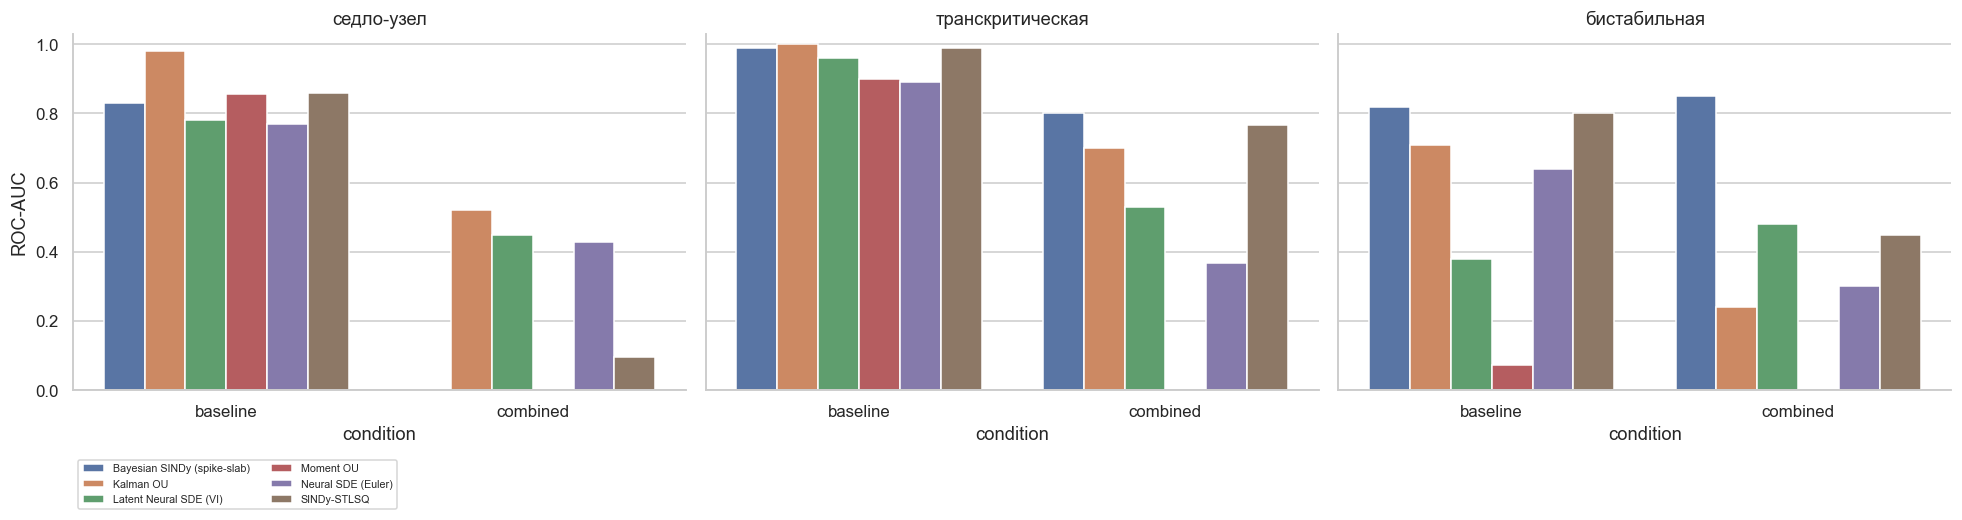

In [36]:
display(nonlinear_alarm.sort_values(["condition", "system", "detection_stability_loss"], ascending=[True, True, False]).style.format({
    "false_alarm_stationary": "{:.1%}", "false_alarm_noise_growth": "{:.1%}",
    "detection_stability_loss": "{:.1%}", "path_coverage": "{:.1%}", "median_lead_time": "{:.1f}",
}))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, system in zip(axes, nonlinear_systems.SYSTEMS):
    block = nonlinear_discrimination.query("system == @system")
    sns.barplot(block, x="condition", y="ROC-AUC", hue="method", ax=ax)
    ax.set_title(system_labels[system])
    ax.set_ylim(0, 1.03)
    if ax is not axes[0]:
        ax.get_legend().remove()
axes[0].legend(fontsize=7, title="", bbox_to_anchor=(0, -0.18), loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

### 8.4. Роль скрытого состояния в Neural SDE

Neural SDE с наблюдаемым и скрытым состоянием сопоставляются по скорости восстановления, диффузии, шуму измерения, доле успешных оценок и ROC-AUC.

In [37]:
# --- Сравнение двух вариантов Neural SDE ---------------------------------------
neural_methods = ["Neural SDE (Euler)", "Latent Neural SDE (VI)"]
nonlinear_neural_comparison = (
    nonlinear_parameter_metrics[nonlinear_parameter_metrics["method"].isin(neural_methods)]
    .merge(nonlinear_discrimination, on=["condition", "system", "method"], how="left")
    .sort_values(["condition", "system", "method"])
)

Только модель со скрытым состоянием отдельно оценивает шум измерения $\tau$. Это не гарантирует меньшей ошибки сноса или лучшей классификации.

In [38]:
display(nonlinear_neural_comparison.style.format({
    "kappa_RMSE": "{:.3f}", "sigma_RMSE": "{:.3f}", "tau_RMSE": "{:.3f}",
    "fit_coverage": "{:.1%}", "ROC-AUC": "{:.3f}", "test_coverage": "{:.1%}",
    "n_test_x": "{:.0f}", "n_test_y": "{:.0f}",
}))

,condition,system,method,kappa_RMSE,sigma_RMSE,tau_RMSE,n_test_x,fit_coverage,ROC-AUC,test_coverage,n_test_y
0,baseline,bistable,Latent Neural SDE (VI),2.406,0.047,0.023,20,100.0%,0.380,125.0%,20
1,baseline,bistable,Neural SDE (Euler),2.389,0.051,nan,20,100.0%,0.640,125.0%,20
2,baseline,saddle_node,Latent Neural SDE (VI),2.289,0.050,0.023,20,100.0%,0.780,125.0%,20
3,baseline,saddle_node,Neural SDE (Euler),2.296,0.053,nan,20,100.0%,0.770,125.0%,20
4,baseline,transcritical,Latent Neural SDE (VI),2.294,0.048,0.023,20,100.0%,0.960,125.0%,20
5,baseline,transcritical,Neural SDE (Euler),2.292,0.052,nan,20,100.0%,0.890,125.0%,20
6,combined,bistable,Latent Neural SDE (VI),1.031,0.080,0.066,20,100.0%,0.480,125.0%,20
7,combined,bistable,Neural SDE (Euler),1.560,0.043,nan,9,55.6%,0.300,56.2%,9
8,combined,saddle_node,Latent Neural SDE (VI),1.111,0.038,0.070,20,100.0%,0.450,125.0%,20
9,combined,saddle_node,Neural SDE (Euler),1.542,0.073,nan,10,46.7%,0.429,62.5%,10


Ранжирование методов зависит от нормальной формы и режима наблюдений. Покрытие интервала необходимо сопоставлять с его шириной.

## 9. Неопределенность для одной траектории

Для индивидуальной траектории применяется блочный бутстреп со скользящими
блоками. Блоки сохраняют часть временной зависимости внутри раннего и позднего
окон. Рассчитываются интервалы и вероятности направленных изменений:
$P(\kappa_{late}<\kappa_{early})$ и
$P(\sigma_{late}>\sigma_{early})$.

In [39]:
def moving_block_sample(values: np.ndarray, random_state: np.random.Generator) -> np.ndarray:
    # Круговой блочный бутстреп со скользящими блоками и сохранением NaN.
    values = np.asarray(values)
    n = len(values)
    block_length = max(3, int(round(n ** (1 / 3))))
    starts = random_state.integers(0, n, size=int(np.ceil(n / block_length)))
    circular = np.concatenate([values, values[: block_length - 1]])
    sampled = np.concatenate([circular[start : start + block_length] for start in starts])
    return sampled[:n]


def bootstrap_change_probabilities(
    observed: pd.DataFrame,
    cfg: ExperimentConfig,
    early_end: float = 25.0,
    late_end: float = 78.0,
    n_bootstrap: int = 600,
    seed: int = SEED + 2,
) -> pd.DataFrame:
    random_state = np.random.default_rng(seed)
    rows = []

    windows = {}
    for name, window_end in {"early": early_end, "late": late_end}.items():
        mask = (
            (observed["time"] > window_end - cfg.window_width)
            & (observed["time"] <= window_end)
        )
        windows[name] = observed.loc[mask, ["time", "value"]].reset_index(drop=True)

    for repetition in range(n_bootstrap):
        estimates = {}
        for name, frame in windows.items():
            sampled_values = moving_block_sample(frame["value"].to_numpy(), random_state)
            estimates[name] = estimate_local_dynamics(
                frame["time"].to_numpy(), sampled_values,
                frame["time"].iloc[-1], cfg.window_width,
                cfg.measurement_noise_sd,
            )
        rows.append({
            "kappa_change": estimates["late"]["kappa_hat"] - estimates["early"]["kappa_hat"],
            "sigma_change": estimates["late"]["sigma_hat"] - estimates["early"]["sigma_hat"],
        })

    return pd.DataFrame(rows)


uncertainty_example = simulate_observations(
    "stability_loss", BASE_CONFIG, np.random.default_rng(991)
)
bootstrap = bootstrap_change_probabilities(uncertainty_example, BASE_CONFIG)

probability_kappa_declines = (bootstrap["kappa_change"] < 0).mean()
probability_sigma_grows = (bootstrap["sigma_change"] > 0).mean()
intervals = bootstrap.quantile([0.025, 0.5, 0.975]).T
intervals.columns = ["2.5%", "median", "97.5%"]

display(intervals.style.format("{:.3f}"))

,2.5%,median,97.5%
kappa_change,-1.378,0.817,3.127
sigma_change,-0.086,0.017,0.129


Для показанной траектории $P(\kappa_{late}<\kappa_{early})=22,0\%$, $P(\sigma_{late}>\sigma_{early})=60,8\%$.

Данных одной траектории недостаточно для уверенного вывода о механизме изменения.

# Часть II. Эпидемиологические данные

## 10. COVID-19: исходные данные и прогнозирование

В статье Лазутова и Леоненко (2026, DOI
[10.7868/S2413977726060056](https://doi.org/10.7868/S2413977726060056))
используются ежедневные данные Санкт-Петербурга из репозитория
[COVID-19.SPb.monitoring](https://github.com/alexei-kouprianov/COVID-19.SPb.monitoring).
Целевой ряд описан как доля положительных тестов. В ноутбуке используется
зафиксированная формула `CONFIRMED.sk / PCR_TESTS`; это аналитическое допущение.

В репозитории сохранен исходный CSV версии
`77e44c9194ba209d69bc6ef082d05be347e04903`; источник указан в `README.md`.

In [40]:
def resolve_data_file(filename: str) -> Path:
    # Работает из корня проекта и при запуске ноутбука из каталога outputs.
    candidates = [
        Path("data") / filename,
        Path("../data") / filename,
        Path("outputs/data") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Не найден {filename}. Ожидался в data/ рядом с репозиторием."
    )


COVID_DATA_PATH = resolve_data_file("SPb.COVID-19.united.csv")
covid_raw = pd.read_csv(COVID_DATA_PATH)
covid_raw["date"] = pd.to_datetime(covid_raw["DATE.spb"], errors="coerce")

covid = (
    covid_raw.dropna(subset=["date"])
    .drop_duplicates(subset=["date"], keep="last")
    .set_index("date")
    .sort_index()
)
daily_index = pd.date_range(covid.index.min(), covid.index.max(), freq="D")
covid = covid.reindex(daily_index)
covid.index.name = "date"

raw_positivity = covid["CONFIRMED.sk"] / covid["PCR_TESTS"]
invalid_positivity = (
    (covid["PCR_TESTS"] <= 0)
    | (raw_positivity < 0)
    | (raw_positivity > 1)
)
covid["positivity"] = raw_positivity.mask(invalid_positivity)

first_valid = covid["positivity"].first_valid_index()
last_valid = covid["positivity"].last_valid_index()
covid = covid.loc[first_valid:last_valid].copy()

# Формула статьи использует только 14 предыдущих значений [k-14, k-1].
covid["positivity_7d"] = covid["positivity"].rolling(7, min_periods=4).mean()
past_positivity = covid["positivity"].shift(1)
covid["ews_mean_14d"] = past_positivity.rolling(14, min_periods=8).mean()
covid["ews_variance_14d"] = past_positivity.rolling(14, min_periods=8).var()

clipped = covid["positivity_7d"].clip(1e-4, 1 - 1e-4)
covid["logit_positivity_7d"] = np.log(clipped / (1.0 - clipped))

n = len(covid)
train_end_position = int(np.ceil(0.70 * n))
validation_end_position = train_end_position + int(np.ceil(0.10 * n))
train_end_date = covid.index[min(train_end_position - 1, n - 1)]
validation_end_date = covid.index[min(validation_end_position - 1, n - 1)]

quality_report = pd.DataFrame({
    "Показатель": [
        "Период", "Календарных дней", "Исходно отсутствует доля положительных тестов",
        "Невозможные значения вне [0, 1]", "Медиана доли положительных тестов",
        "Граница обучающей выборки, 70%", "Граница валидационной выборки, 10%",
    ],
    "Значение": [
        f"{covid.index.min().date()} — {covid.index.max().date()}",
        f"{len(covid):,}",
        f"{covid['positivity'].isna().sum():,}",
        f"{invalid_positivity.sum():,}",
        f"{covid['positivity'].median():.3f}",
        str(train_end_date.date()),
        str(validation_end_date.date()),
    ],
})
display(quality_report)

,Показатель,Значение
0,Период,2020-03-29 — 2024-03-11
1,Календарных дней,"1,444"
2,Исходно отсутствует доля положительных тестов,56
3,"Невозможные значения вне [0, 1]",1
4,Медиана доли положительных тестов,0.066
5,"Граница обучающей выборки, 70%",2023-01-03
6,"Граница валидационной выборки, 10%",2023-05-28


Пропуски не интерполируются. Единственное невозможное значение доли положительных тестов исключено правилом $[0,1]$; границы выборок определяются по календарю до построения прогнозных примеров.

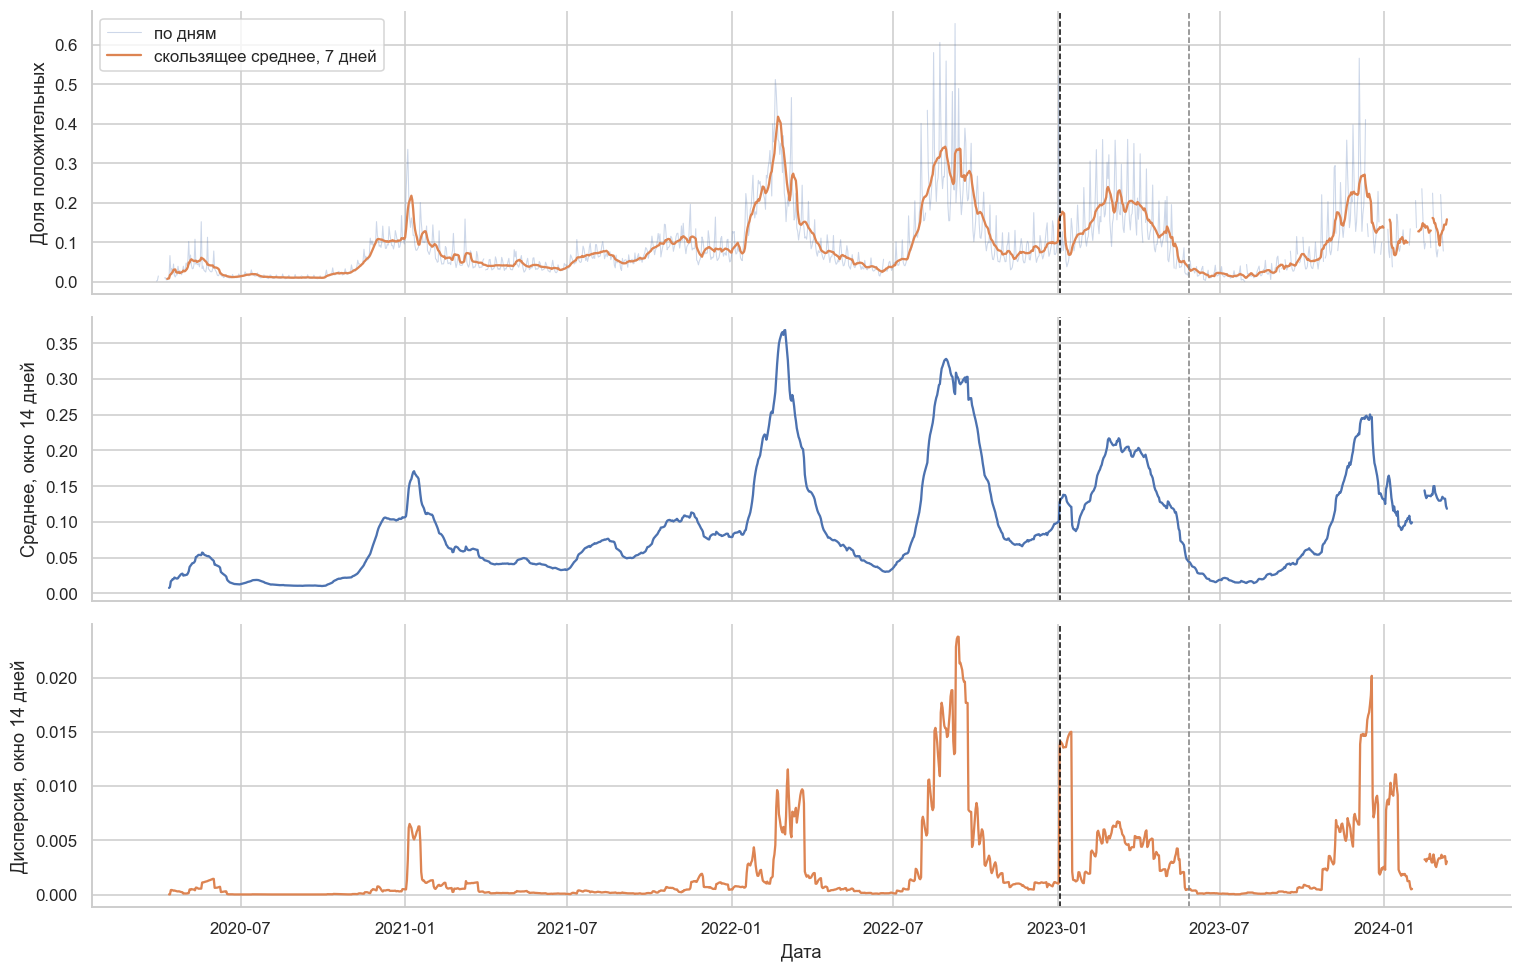

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(covid.index, covid["positivity"], alpha=0.28, lw=0.7, label="по дням")
axes[0].plot(covid.index, covid["positivity_7d"], lw=1.5, label="скользящее среднее, 7 дней")
axes[0].set_ylabel("Доля положительных")
axes[0].legend()

axes[1].plot(covid.index, covid["ews_mean_14d"], color="#4c72b0")
axes[1].set_ylabel("Среднее, окно 14 дней")
axes[2].plot(covid.index, covid["ews_variance_14d"], color="#dd8452")
axes[2].set_ylabel("Дисперсия, окно 14 дней")

for ax in axes:
    ax.axvline(train_end_date, color="black", ls="--", lw=1, label="70%: обучение")
    ax.axvline(validation_end_date, color="grey", ls="--", lw=1, label="10%: валидация")
axes[2].set_xlabel("Дата")
plt.tight_layout()
plt.show()

Скользящее среднее сохраняет форму волн, а дисперсия образует более узкие пики и сильнее штрафует ошибку в дате прогноза.

### Критерий начала эпидемической волны

Критерий статьи применяется к недельному ряду ОРВИ с официальным индикатором
превышения сезонного эпидемического порога:

- $Y_k=1$, если индикатор сообщает о превышении порога, и $Y_k=0$ иначе;
- $E_l$ - первая неделя ближайшего эпидемического периода;
- $I_l$ - последняя неделя 30-недельного входного окна;
- метка раннего предупреждения равна $Y'_l=1[E_l-I_l\le t]$ при $t=4$ или
  $t=5$, то есть на горизонте 28 или 35 дней.

Для немаркированного ряда COVID-19 используется регрессионная постановка:
прогноз 14-дневных скользящих среднего и дисперсии на 14 и 28 дней.

In [42]:
article_design = pd.DataFrame({
    "Часть статьи": ["ОРВИ: классификация", "COVID-19: регрессия"],
    "Данные": [
        "1990-2019, недельные данные с разметкой НИИ гриппа",
        "2020-2024, ежедневные открытые данные",
    ],
    "Цель": [
        "До официального превышения эпидпорога",
        "Будущие 14-дневные среднее и дисперсия доли положительных тестов",
    ],
    "Горизонты": ["4/5 недель (28/35 дней)", "14/28 дней"],
    "Модели": [
        "Decision Tree, Random Forest, Easy Ensemble, RUSBoost, "
        "Balanced Bagging, EWSNet",
        "LSTM, GRU",
    ],
})
display(article_design)

published_regression = pd.DataFrame([
    ("GRU", "mean", 14, 0.038, 0.057, 0.960),
    ("GRU", "variance", 14, 0.058, 0.125, 0.697),
    ("GRU", "mean", 28, 0.074, 0.113, 0.838),
    ("GRU", "variance", 28, 0.077, 0.139, 0.494),
    ("LSTM", "mean", 14, 0.032, 0.055, 0.961),
    ("LSTM", "variance", 14, 0.063, 0.131, 0.652),
    ("LSTM", "mean", 28, 0.054, 0.094, 0.899),
    ("LSTM", "variance", 28, 0.077, 0.123, 0.578),
], columns=["model", "target", "horizon", "NMAE", "NRMSE", "R2"])

,Часть статьи,Данные,Цель,Горизонты,Модели
0,ОРВИ: классификация,"1990-2019, недельные данные с разметкой НИИ гр...",До официального превышения эпидпорога,4/5 недель (28/35 дней),"Decision Tree, Random Forest, Easy Ensemble, R..."
1,COVID-19: регрессия,"2020-2024, ежедневные открытые данные",Будущие 14-дневные среднее и дисперсия доли по...,14/28 дней,"LSTM, GRU"


#### Контрольные значения из статьи

In [43]:
display(
    published_regression.sort_values(["target", "horizon", "model"])
    .style.format({"NMAE": "{:.3f}", "NRMSE": "{:.3f}", "R2": "{:.3f}"})
)

,model,target,horizon,NMAE,NRMSE,R2
0,GRU,mean,14,0.038,0.057,0.960
4,LSTM,mean,14,0.032,0.055,0.961
2,GRU,mean,28,0.074,0.113,0.838
6,LSTM,mean,28,0.054,0.094,0.899
1,GRU,variance,14,0.058,0.125,0.697
5,LSTM,variance,14,0.063,0.131,0.652
3,GRU,variance,28,0.077,0.139,0.494
7,LSTM,variance,28,0.077,0.123,0.578


COVID-ряд используется для регрессии, поскольку не содержит официальных меток начала волны. Классификация проводится отдельно на размеченном недельном ряду ОРВИ.

### Локальная динамика эпидемиологического ряда

В каждом причинном окне длиной 56 дней из логита доли положительных тестов удаляется линейный тренд, затем раз в неделю оценивается локальная OU-модель в пространстве состояний. Удаление тренда отделяет изменение среднего уровня заболеваемости от критического замедления. Скользящие среднее и дисперсия воспроизводят регрессионную постановку статьи.

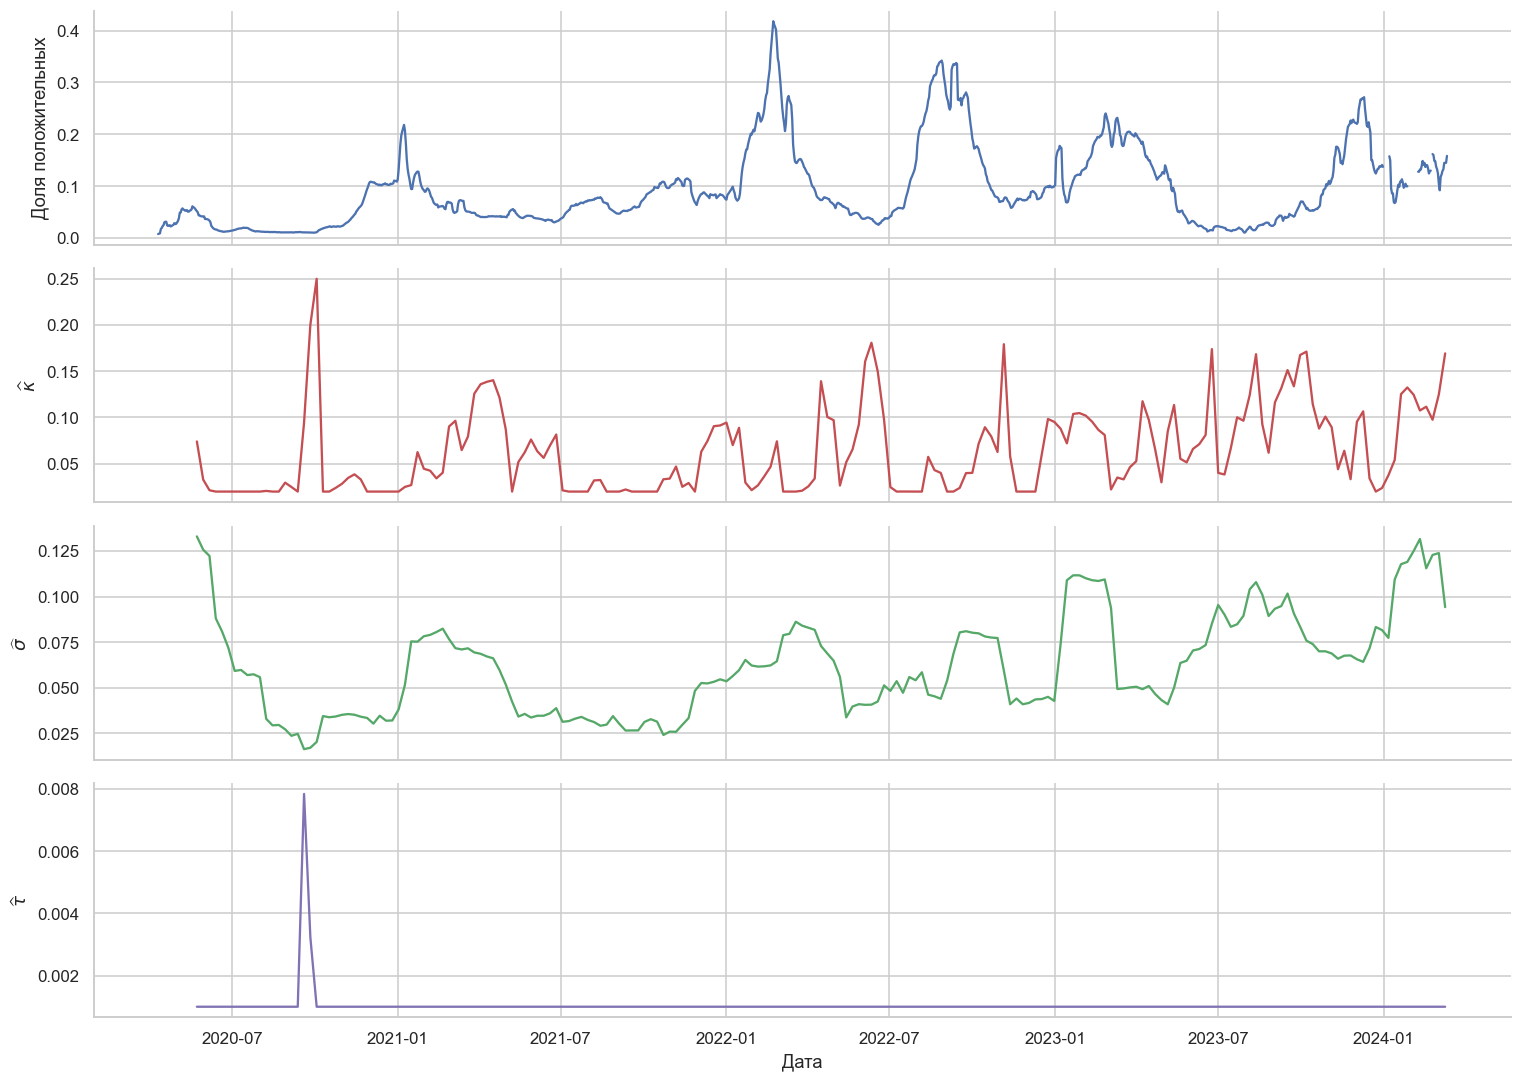

In [44]:
def fit_real_data_window(
    series: pd.Series,
    window_end: pd.Timestamp,
    window_days: int = 56,
) -> Dict[str, float]:
    start = window_end - pd.Timedelta(days=window_days - 1)
    window = series.loc[start:window_end]
    time = np.arange(len(window), dtype=float)
    values = window.to_numpy(dtype=float)
    finite = np.isfinite(values)

    if finite.sum() < 35:
        return {
            "date": window_end, "kappa_hat": np.nan, "sigma_hat": np.nan,
            "measurement_noise_hat": np.nan, "residual_variance": np.nan,
            "converged": False,
        }

    slope, intercept = np.polyfit(time[finite], values[finite], deg=1)
    residuals = values - (intercept + slope * time)
    fitted = fit_local_ou_kalman(time, residuals)
    return {
        "date": window_end,
        "kappa_hat": fitted["kappa_hat"],
        "sigma_hat": fitted["sigma_hat"],
        "measurement_noise_hat": fitted["measurement_noise_hat"],
        "residual_variance": np.nanvar(residuals, ddof=1),
        "converged": fitted["converged"],
    }


real_window_ends = pd.date_range(
    covid.index.min() + pd.Timedelta(days=55),
    covid.index.max(),
    freq="7D",
)
real_dynamics = pd.DataFrame([
    fit_real_data_window(covid["logit_positivity_7d"], window_end)
    for window_end in real_window_ends
]).set_index("date")


fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(covid.index, covid["positivity_7d"], color="#4c72b0")
axes[0].set_ylabel("Доля положительных")
axes[1].plot(real_dynamics.index, real_dynamics["kappa_hat"], color="#c44e52")
axes[1].set_ylabel(r"$\widehat\kappa$")
axes[2].plot(real_dynamics.index, real_dynamics["sigma_hat"], color="#55a868")
axes[2].set_ylabel(r"$\widehat\sigma$")
axes[3].plot(
    real_dynamics.index, real_dynamics["measurement_noise_hat"], color="#8172b3"
)
axes[3].set_ylabel(r"$\widehat\tau$")
axes[3].set_xlabel("Дата")
plt.tight_layout()
plt.show()

Локальные параметры меняются во времени, но без меток начала волны их нельзя перевести в полноту обнаружения или время упреждения.

### Сравнение прогнозов: LSTM, GRU, Persistence и Local Kalman-OU

Воспроизводятся явно указанные в статье параметры: одномерное входное окно
длины 20, один слой LSTM или GRU со 128 ячейками, оптимизатор Adam и 100 эпох.
Остальные настройки зафиксированы в ноутбуке: размер пакета 32, функция потерь
MSE, один линейный выход и `shuffle=False`.

При прямом прогнозе 20 прошлых значений EWS используются для оценки значения
того же EWS через 14 или 28 дней. Дата целевого значения определяет
принадлежность к хронологическому разбиению 70/10/20. Масштабирование оценивается
только на обучающей выборке. Предсказания нейросетей сохранены в данных;
`RETRAIN_NEURAL_MODELS=True` запускает обучение заново.

На одинаковых датах формирования и проверки прогноза добавлены Persistence и
Local Kalman-OU. Вторая модель сочетает локальный линейный тренд и OU-остаток,
оцененный методом максимального правдоподобия Калмана по последним 56 дням.

### Анализ чувствительности реконструкции доли положительных тестов

Перед моделированием сравниваются две формулы доли положительных тестов и три
способа обработки значений вне допустимого диапазона. Основная спецификация
задана заранее: `CONFIRMED.sk / PCR_TESTS`, значения вне $[0,1]$ заменяются на
`NaN`.

,formula,n_finite,n_above_1,median,p99,maximum
0,CONFIRMED.sk / PCR_TESTS,1389,1,0.0658,0.4213,94.000
1,CONFIRMED.spb / PCR_TESTS,172,0,0.0554,0.1652,0.202


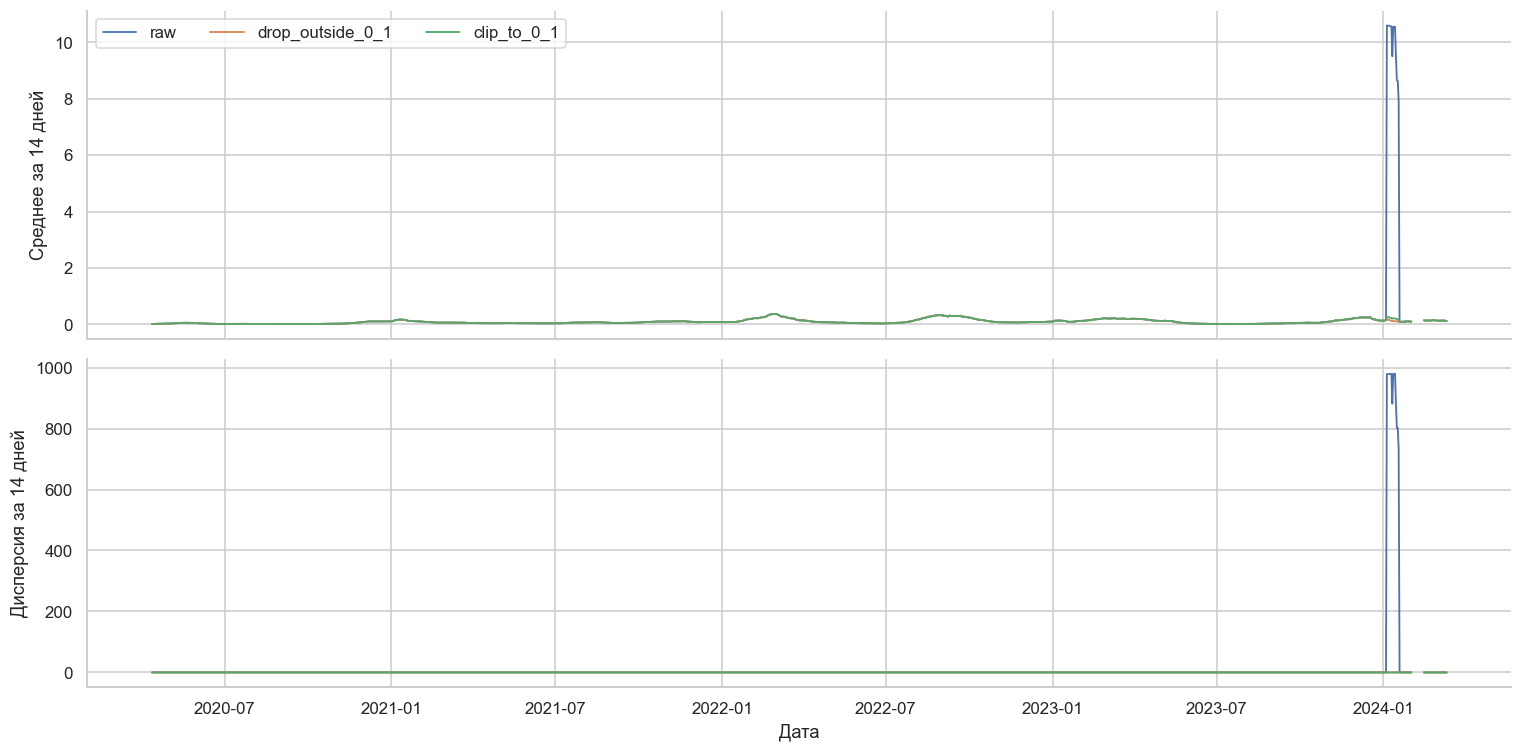

In [45]:
# Проверка реконструкции доли положительных тестов.
ratio_candidates = pd.DataFrame(index=covid.index)
ratio_candidates["CONFIRMED.sk / PCR_TESTS"] = covid["CONFIRMED.sk"] / covid["PCR_TESTS"]
ratio_candidates["CONFIRMED.spb / PCR_TESTS"] = covid["CONFIRMED.spb"] / covid["PCR_TESTS"]

positivity_audit = []
for name, values in ratio_candidates.items():
    finite = values.replace([np.inf, -np.inf], np.nan).dropna()
    positivity_audit.append({
        "formula": name,
        "n_finite": len(finite),
        "n_above_1": int((finite > 1).sum()),
        "median": finite.median(),
        "p99": finite.quantile(0.99),
        "maximum": finite.max(),
    })
positivity_audit = pd.DataFrame(positivity_audit)
display(positivity_audit.style.format({"median": "{:.4f}", "p99": "{:.4f}", "maximum": "{:.3f}"}))

sk_raw = ratio_candidates["CONFIRMED.sk / PCR_TESTS"]
sanitation_sensitivity = pd.DataFrame({
    "raw": sk_raw,
    "drop_outside_0_1": sk_raw.where(sk_raw.between(0, 1)),
    "clip_to_0_1": sk_raw.clip(0, 1),
})
sanitation_summary = sanitation_sensitivity.shift(1).rolling(14, min_periods=8).agg(["mean", "var"])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for policy in sanitation_sensitivity.columns:
    axes[0].plot(sanitation_summary.index, sanitation_summary[(policy, "mean")], label=policy, lw=1.2)
    axes[1].plot(sanitation_summary.index, sanitation_summary[(policy, "var")], label=policy, lw=1.2)
axes[0].set_ylabel("Среднее за 14 дней")
axes[1].set_ylabel("Дисперсия за 14 дней")
axes[1].set_xlabel("Дата")
axes[0].legend(ncol=3)
plt.tight_layout()
plt.show()

Основная формула `CONFIRMED.sk / PCR_TESTS` дает почти полный ряд. Единственный выброс вне $[0,1]$ удаляется до построения признаков.

In [46]:
RETRAIN_NEURAL_MODELS = False
ARTICLE_INPUT_WINDOW = 20
ARTICLE_HIDDEN_UNITS = 128
ARTICLE_EPOCHS = 100
ARTICLE_BATCH_SIZE = 32


class ArticleRecurrentRegressor(nn.Module):
    def __init__(self, architecture: str):
        super().__init__()
        recurrent_layer = nn.LSTM if architecture == "LSTM" else nn.GRU
        self.recurrent = recurrent_layer(
            input_size=1,
            hidden_size=ARTICLE_HIDDEN_UNITS,
            num_layers=1,
            batch_first=True,
        )
        self.output = nn.Linear(ARTICLE_HIDDEN_UNITS, 1)

    def forward(self, values: torch.Tensor) -> torch.Tensor:
        sequence, _ = self.recurrent(values)
        return self.output(sequence[:, -1, :]).squeeze(-1)


def make_direct_forecast_samples(
    series: pd.Series,
    horizon: int,
    input_window: int = ARTICLE_INPUT_WINDOW,
):
    values = series.to_numpy(dtype=float)
    rows = []
    for origin in range(input_window - 1, len(values) - horizon):
        history = values[origin - input_window + 1 : origin + 1]
        target = values[origin + horizon]
        if np.isfinite(history).all() and np.isfinite(target):
            rows.append(
                (history, target, series.index[origin], series.index[origin + horizon])
            )
    histories, targets, origins, target_dates = zip(*rows)
    return (
        np.asarray(histories),
        np.asarray(targets),
        pd.DatetimeIndex(origins),
        pd.DatetimeIndex(target_dates),
    )


def train_article_recurrent_model(
    architecture: str,
    target_name: str,
    horizon: int,
) -> pd.DataFrame:
    # Полная процедура обучения; вызывается при RETRAIN_NEURAL_MODELS=True.
    series = covid[f"ews_{target_name}_14d"]
    x, y, origin_dates, target_dates = make_direct_forecast_samples(series, horizon)
    train = target_dates <= train_end_date
    test = target_dates > validation_end_date

    scaler = StandardScaler().fit(
        np.concatenate([x[train].ravel(), y[train]]).reshape(-1, 1)
    )
    x_scaled = scaler.transform(x.reshape(-1, 1)).reshape(
        len(x), ARTICLE_INPUT_WINDOW, 1
    )
    y_scaled = scaler.transform(y.reshape(-1, 1)).ravel()

    task_seed = (
        SEED
        + horizon
        + 100 * (target_name == "variance")
        + 1000 * (architecture == "LSTM")
    )
    torch.manual_seed(task_seed)
    torch.set_num_threads(2)
    model = ArticleRecurrentRegressor(architecture)
    optimizer = torch.optim.Adam(model.parameters())
    loss_function = nn.MSELoss()
    x_train = torch.tensor(x_scaled[train], dtype=torch.float32)
    y_train = torch.tensor(y_scaled[train], dtype=torch.float32)

    for _ in range(ARTICLE_EPOCHS):
        model.train()
        for start in range(0, len(x_train), ARTICLE_BATCH_SIZE):
            x_batch = x_train[start : start + ARTICLE_BATCH_SIZE]
            y_batch = y_train[start : start + ARTICLE_BATCH_SIZE]
            optimizer.zero_grad()
            loss = loss_function(model(x_batch), y_batch)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        prediction_scaled = model(
            torch.tensor(x_scaled[test], dtype=torch.float32)
        ).numpy()
    prediction = scaler.inverse_transform(prediction_scaled.reshape(-1, 1)).ravel()

    return pd.DataFrame(
        {
            "architecture": architecture,
            "target": target_name,
            "horizon": horizon,
            "origin_date": origin_dates[test],
            "target_date": target_dates[test],
            "y_true": y[test],
            "prediction": prediction,
        }
    )


NEURAL_PREDICTIONS_PATH = resolve_data_file("article_neural_predictions.csv")
if RETRAIN_NEURAL_MODELS:
    neural_parts = [
        train_article_recurrent_model(architecture, target, horizon)
        for architecture in ["GRU", "LSTM"]
        for target in ["mean", "variance"]
        for horizon in [14, 28]
    ]
    neural_predictions = pd.concat(neural_parts, ignore_index=True)
else:
    neural_predictions = pd.read_csv(
        NEURAL_PREDICTIONS_PATH,
        parse_dates=["origin_date", "target_date"],
    )


In [47]:
def filter_last_ou_state(
    residuals: np.ndarray,
    kappa: float,
    process_sigma: float,
    measurement_noise: float,
) -> float:
    stationary_variance = process_sigma**2 / (2.0 * kappa)
    filtered_mean = 0.0
    filtered_variance = stationary_variance
    for i, observation in enumerate(residuals):
        if i > 0:
            phi = np.exp(-kappa)
            innovation_variance = stationary_variance * (1.0 - phi**2)
            filtered_mean *= phi
            filtered_variance = phi**2 * filtered_variance + innovation_variance
        if np.isfinite(observation):
            prediction_variance = filtered_variance + measurement_noise**2
            gain = filtered_variance / prediction_variance
            filtered_mean += gain * (observation - filtered_mean)
            filtered_variance = max((1.0 - gain) * filtered_variance, 1e-12)
    return float(filtered_mean)


def local_kalman_forecast(
    series: pd.Series,
    origin_date: pd.Timestamp,
    horizon: int,
    local_window: int = 56,
) -> float:
    origin_position = series.index.get_loc(origin_date)
    history = series.iloc[
        max(0, origin_position - local_window + 1) : origin_position + 1
    ]
    values = history.to_numpy(dtype=float)
    time = np.arange(len(values), dtype=float)
    finite = np.isfinite(values)
    if finite.sum() < 35:
        return np.nan

    slope, intercept = np.polyfit(time[finite], values[finite], deg=1)
    residuals = values - (intercept + slope * time)
    residuals -= np.nanmean(residuals)
    fitted = fit_local_ou_kalman(time, residuals)
    if not fitted["converged"]:
        return np.nan

    last_state = filter_last_ou_state(
        residuals,
        fitted["kappa_hat"],
        fitted["sigma_hat"],
        fitted["measurement_noise_hat"],
    )
    residual_forecast = last_state * np.exp(-fitted["kappa_hat"] * horizon)
    trend_forecast = intercept + slope * (len(values) - 1 + horizon)
    return float(trend_forecast + residual_forecast)


baseline_rows = []
unique_tasks = neural_predictions.drop_duplicates(
    ["target", "horizon", "origin_date", "target_date"]
)
for _, row in unique_tasks.iterrows():
    target_column = f"ews_{row['target']}_14d"
    series = covid[target_column]
    origin_date = pd.Timestamp(row["origin_date"])
    prediction_kalman = local_kalman_forecast(
        series, origin_date, int(row["horizon"])
    )
    prediction_kalman = (
        np.clip(prediction_kalman, 0.0, 1.0)
        if row["target"] == "mean"
        else max(prediction_kalman, 0.0)
    )
    baseline_rows.extend(
        [
            {
                "architecture": "Persistence",
                "target": row["target"],
                "horizon": int(row["horizon"]),
                "origin_date": origin_date,
                "target_date": pd.Timestamp(row["target_date"]),
                "y_true": row["y_true"],
                "prediction": series.loc[origin_date],
            },
            {
                "architecture": "Local Kalman-OU",
                "target": row["target"],
                "horizon": int(row["horizon"]),
                "origin_date": origin_date,
                "target_date": pd.Timestamp(row["target_date"]),
                "y_true": row["y_true"],
                "prediction": prediction_kalman,
            },
        ]
    )

forecast_predictions = pd.concat(
    [
        neural_predictions[
            [
                "architecture",
                "target",
                "horizon",
                "origin_date",
                "target_date",
                "y_true",
                "prediction",
            ]
        ],
        pd.DataFrame(baseline_rows),
    ],
    ignore_index=True,
)


def regression_metrics(group: pd.DataFrame) -> pd.Series:
    complete = group.dropna(subset=["y_true", "prediction"])
    scale = np.ptp(complete["y_true"])
    mae = mean_absolute_error(complete["y_true"], complete["prediction"])
    rmse = np.sqrt(mean_squared_error(complete["y_true"], complete["prediction"]))
    return pd.Series(
        {
            "MAE": mae,
            "RMSE": rmse,
            "NMAE": mae / scale,
            "NRMSE": rmse / scale,
            "R2": r2_score(complete["y_true"], complete["prediction"]),
            "n_test": len(complete),
        }
    )


forecast_metrics = (
    forecast_predictions.groupby(["architecture", "target", "horizon"])
    .apply(regression_metrics, include_groups=False)
    .reset_index()
)

display(
    forecast_metrics.sort_values(["target", "horizon", "NRMSE"])
    .style.format(
        {
            "MAE": "{:.5f}",
            "RMSE": "{:.5f}",
            "NMAE": "{:.3f}",
            "NRMSE": "{:.3f}",
            "R2": "{:.3f}",
            "n_test": "{:.0f}",
        }
    )
    .background_gradient(subset=["NRMSE"], cmap="RdYlGn_r")
)

,architecture,target,horizon,MAE,RMSE,NMAE,NRMSE,R2,n_test
12,Persistence,mean,14,0.02477,0.03627,0.105,0.154,0.728,250
4,LSTM,mean,14,0.02563,0.03917,0.109,0.166,0.682,250
0,GRU,mean,14,0.02448,0.04044,0.104,0.172,0.662,250
8,Local Kalman-OU,mean,14,0.03263,0.05093,0.138,0.216,0.463,250
1,GRU,mean,28,0.03197,0.03985,0.136,0.169,0.666,264
5,LSTM,mean,28,0.03334,0.04697,0.141,0.199,0.536,264
13,Persistence,mean,28,0.04474,0.05957,0.190,0.253,0.253,264
9,Local Kalman-OU,mean,28,0.05928,0.08764,0.251,0.372,-0.616,264
10,Local Kalman-OU,variance,14,0.00227,0.00420,0.113,0.209,0.047,250
14,Persistence,variance,14,0.00239,0.00440,0.118,0.219,-0.049,250


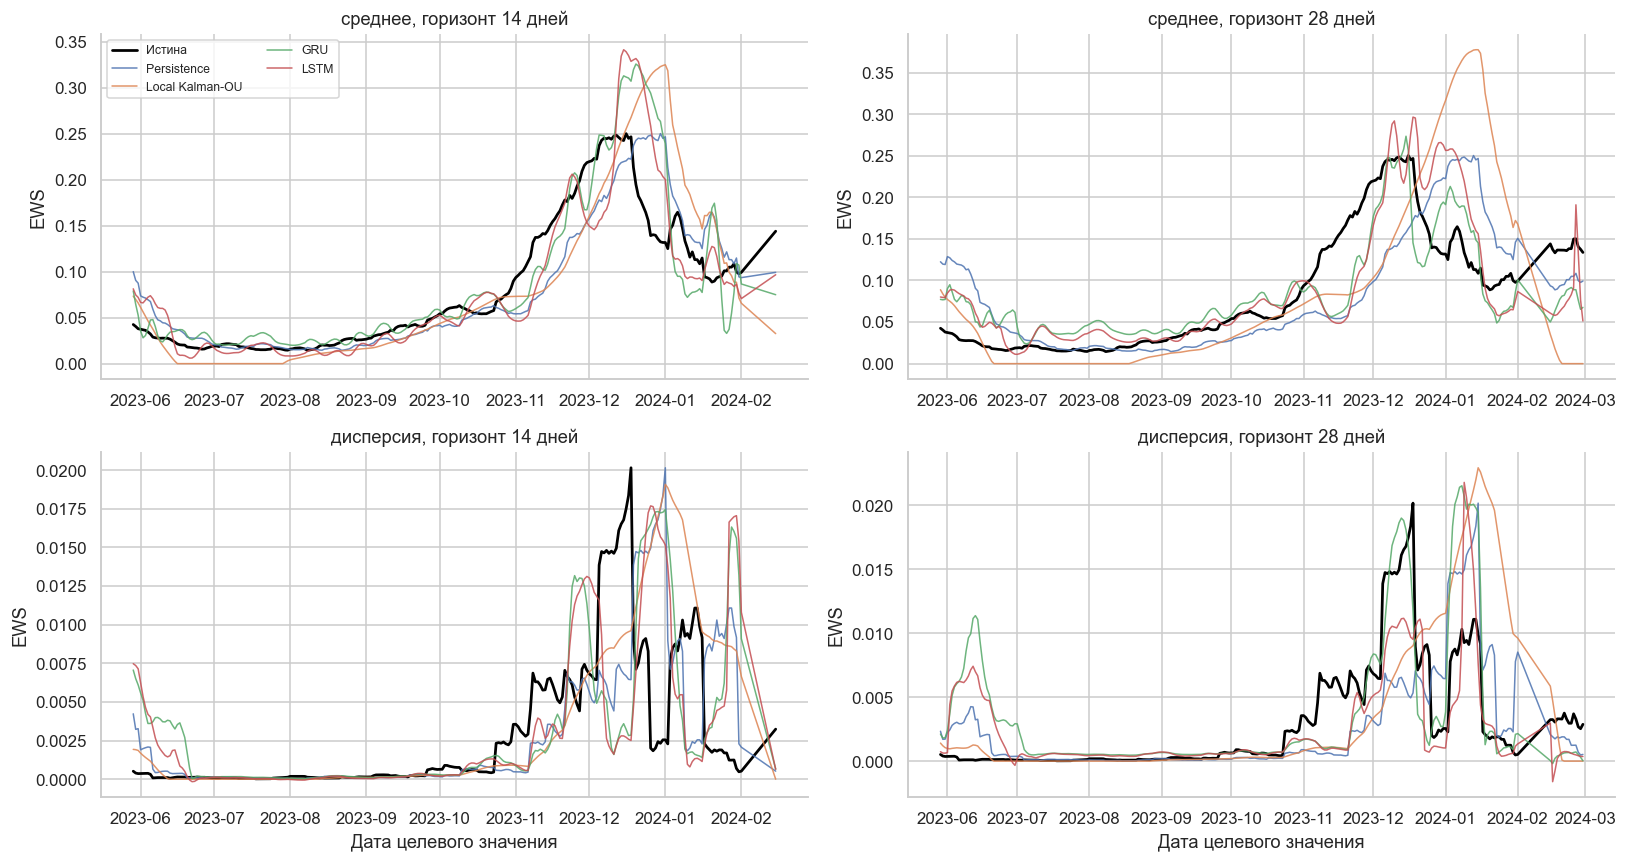

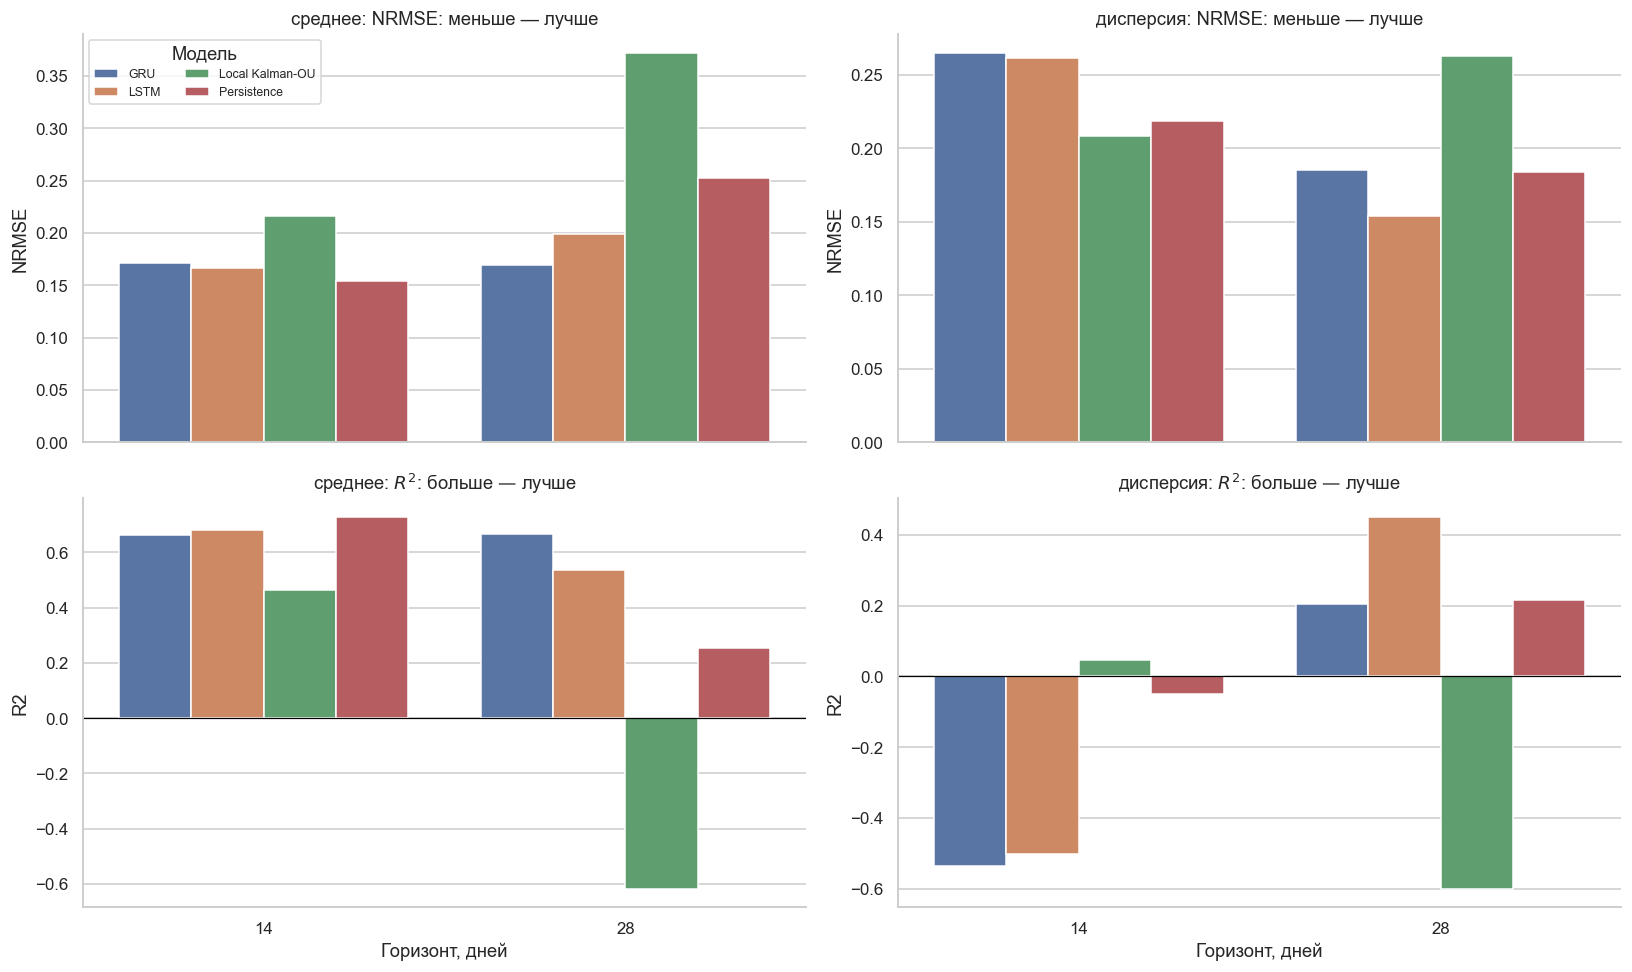

In [48]:
TARGET_LABELS = {"mean": "среднее", "variance": "дисперсия"}

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=False)
for ax, target_name, horizon in zip(
    axes.flat,
    ["mean", "mean", "variance", "variance"],
    [14, 28, 14, 28],
):
    subset = forecast_predictions.query(
        "target == @target_name and horizon == @horizon"
    )
    truth = subset.drop_duplicates("target_date").sort_values("target_date")
    ax.plot(
        truth["target_date"], truth["y_true"],
        color="black", lw=1.8, label="Истина",
    )
    for model_name in ["Persistence", "Local Kalman-OU", "GRU", "LSTM"]:
        model_data = subset.query(
            "architecture == @model_name"
        ).sort_values("target_date")
        ax.plot(
            model_data["target_date"],
            model_data["prediction"],
            lw=1.0,
            alpha=0.85,
            label=model_name,
        )
    ax.set_title(f"{TARGET_LABELS[target_name]}, горизонт {horizon} дней")
    ax.set_ylabel("EWS")
axes[0, 0].legend(fontsize=8, ncol=2)
for ax in axes[1]:
    ax.set_xlabel("Дата целевого значения")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex="col")
for column, target_name in enumerate(["mean", "variance"]):
    target_metrics = forecast_metrics.query("target == @target_name")
    for row, (metric, title) in enumerate(
        [("NRMSE", "NRMSE: меньше — лучше"), ("R2", r"$R^2$: больше — лучше")]
    ):
        ax = axes[row, column]
        sns.barplot(
            target_metrics,
            x="horizon",
            y=metric,
            hue="architecture",
            errorbar=None,
            ax=ax,
        )
        ax.set_title(f"{TARGET_LABELS[target_name]}: {title}")
        ax.set_xlabel("Горизонт, дней" if row == 1 else "")
        if metric == "R2":
            ax.axhline(0, color="black", lw=0.8)
        if not (row == 0 and column == 0):
            ax.get_legend().remove()
axes[0, 0].legend(fontsize=8, ncol=2, title="Модель")
plt.tight_layout()
plt.show()

### Итог сравнения прогнозов

- среднее на 14 дней: **Persistence**, NRMSE 0,154;
- среднее на 28 дней: **GRU**, NRMSE 0,169;
- дисперсия на 14 дней: **Local Kalman-OU**, NRMSE 0,209;
- дисперсия на 28 дней: **LSTM**, NRMSE 0,154.

Победитель зависит от показателя и горизонта. Значения относятся к выбранной схеме хронологической проверки и не считаются точным повторением запуска из статьи.

### Проверка устойчивости: оценивание со скользящим началом и многошаговый прогноз

Хронологическое разбиение 70/10/20 дополняется тремя разбиениями с расширяющимся
обучающим окном. Обучение заканчивается на 60%, 70% и 80% календарного ряда;
следующий блок длиной 10% используется для проверки. Во всех разбиениях
сохраняются 100 эпох и одинаковые архитектуры, а тестовые данные не участвуют в
масштабировании.

На общих датах последнего тестового блока сравниваются три стратегии:
`direct` - отдельная модель сразу для горизонта $h$; `recursive` - итеративная
подача однодневного прогноза на вход; `multi_output` - одновременная оценка
всего вектора из $h$ будущих значений.

In [49]:
rolling_neural = pd.read_csv(
    resolve_data_file("covid_rolling_neural_predictions.csv"),
    parse_dates=["train_end", "test_end", "origin_date", "target_date"],
)

# Одинаковые даты формирования и проверки прогноза для нейросетей и двух базовых моделей.
rolling_baseline_rows = []
rolling_tasks = rolling_neural.drop_duplicates(
    ["target", "horizon", "fold", "origin_date", "target_date"]
)
for row in rolling_tasks.itertuples():
    series = covid[f"ews_{row.target}_14d"]
    kalman_prediction = local_kalman_forecast(series, row.origin_date, int(row.horizon))
    if row.target == "mean":
        kalman_prediction = np.clip(kalman_prediction, 0, 1)
    else:
        kalman_prediction = max(kalman_prediction, 0) if np.isfinite(kalman_prediction) else np.nan
    common = {
        "target": row.target, "horizon": row.horizon, "fold": row.fold,
        "train_end": row.train_end, "test_end": row.test_end,
        "origin_date": row.origin_date, "target_date": row.target_date,
        "y_true": row.y_true,
    }
    rolling_baseline_rows.extend([
        {**common, "architecture": "Persistence", "prediction": series.loc[row.origin_date]},
        {**common, "architecture": "Local Kalman-OU", "prediction": kalman_prediction},
    ])

rolling_predictions = pd.concat(
    [rolling_neural, pd.DataFrame(rolling_baseline_rows)], ignore_index=True
)
rolling_predictions.to_csv(
    Path(resolve_data_file("covid_rolling_neural_predictions.csv")).with_name(
        "covid_rolling_all_predictions.csv"
    ), index=False
)
rolling_fold_metrics = (
    rolling_predictions.groupby(["architecture", "target", "horizon", "fold"])
    .apply(regression_metrics, include_groups=False).reset_index()
)
rolling_summary = (
    rolling_fold_metrics.groupby(["architecture", "target", "horizon"])
    .agg(
        NRMSE_mean=("NRMSE", "mean"),
        NRMSE_sd=("NRMSE", "std"),
        R2_mean=("R2", "mean"),
        folds=("fold", "nunique"),
    ).reset_index()
)

#### Оценивание со скользящим началом

,architecture,target,horizon,NRMSE_mean,NRMSE_sd,R2_mean,folds
12,Persistence,mean,14,0.235,0.043,0.374,3
0,GRU,mean,14,0.245,0.105,0.151,3
8,Local Kalman-OU,mean,14,0.295,0.037,0.089,3
4,LSTM,mean,14,0.323,0.201,-0.721,3
1,GRU,mean,28,0.408,0.123,-1.079,3
5,LSTM,mean,28,0.418,0.155,-1.189,3
13,Persistence,mean,28,0.470,0.192,-1.678,3
9,Local Kalman-OU,mean,28,0.500,0.131,-1.575,3
10,Local Kalman-OU,variance,14,0.403,0.022,-1.520,3
14,Persistence,variance,14,0.442,0.221,-2.746,3


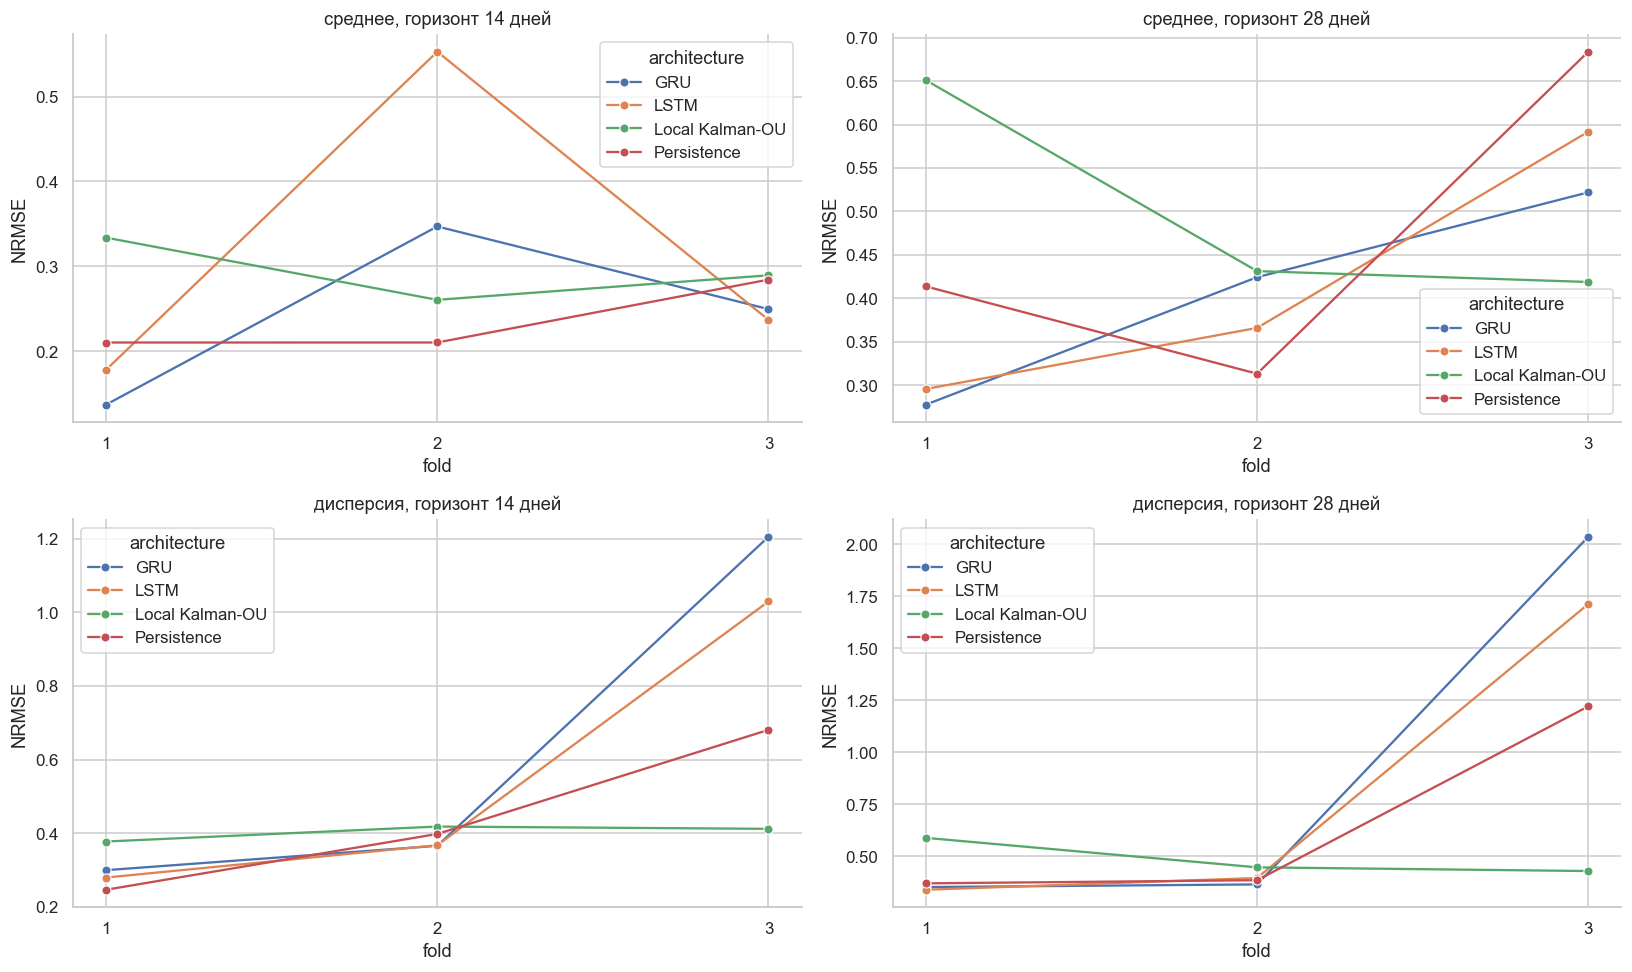

In [50]:
display(
    rolling_summary.sort_values(["target", "horizon", "NRMSE_mean"])
    .style.format({"NRMSE_mean": "{:.3f}", "NRMSE_sd": "{:.3f}", "R2_mean": "{:.3f}", "folds": "{:.0f}"})
    .background_gradient(subset=["NRMSE_mean"], cmap="RdYlGn_r")
)

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=False)
for ax, ((target, horizon), block) in zip(
    axes.flat, rolling_fold_metrics.groupby(["target", "horizon"])
):
    sns.lineplot(block, x="fold", y="NRMSE", hue="architecture", marker="o", ax=ax)
    ax.set_title(f"{TARGET_LABELS[target]}, горизонт {horizon} дней")
    ax.set_xticks([1, 2, 3])
plt.tight_layout()
plt.show()

# Прямой прогноз из предыдущего раздела объединяется с рекурсивным и
# многовыходным прогнозами. Сравниваются только общие даты целевых значений.
direct_strategy = neural_predictions.copy()
direct_strategy["strategy"] = "direct"
strategy_predictions = pd.read_csv(
    resolve_data_file("covid_strategy_predictions.csv"),
    parse_dates=["origin_date", "target_date"],
)
all_strategies = pd.concat([
    direct_strategy[["architecture", "strategy", "target", "horizon", "origin_date", "target_date", "y_true", "prediction"]],
    strategy_predictions,
], ignore_index=True)

common_parts = []
for keys, block in all_strategies.groupby(["architecture", "target", "horizon"]):
    date_sets = [set(group["target_date"]) for _, group in block.groupby("strategy")]
    common_dates = set.intersection(*date_sets)
    common_parts.append(block[block["target_date"].isin(common_dates)])
strategy_common = pd.concat(common_parts, ignore_index=True)
strategy_metrics = (
    strategy_common.groupby(["architecture", "strategy", "target", "horizon"])
    .apply(regression_metrics, include_groups=False).reset_index()
)

#### Стратегии многошагового прогноза

In [51]:
display(
    strategy_metrics.sort_values(["target", "horizon", "architecture", "NRMSE"])
    .style.format({"MAE": "{:.5f}", "RMSE": "{:.5f}", "NMAE": "{:.3f}", "NRMSE": "{:.3f}", "R2": "{:.3f}", "n_test": "{:.0f}"})
    .background_gradient(subset=["NRMSE"], cmap="RdYlGn_r")
)


,architecture,strategy,target,horizon,MAE,RMSE,NMAE,NRMSE,R2,n_test
4,GRU,multi_output,mean,14,0.02125,0.03875,0.090,0.164,0.690,249
0,GRU,direct,mean,14,0.02430,0.04028,0.103,0.171,0.664,249
8,GRU,recursive,mean,14,0.02845,0.04579,0.121,0.194,0.566,249
12,LSTM,direct,mean,14,0.02554,0.03914,0.108,0.166,0.683,249
16,LSTM,multi_output,mean,14,0.03065,0.05141,0.130,0.218,0.453,249
20,LSTM,recursive,mean,14,0.02908,0.05306,0.123,0.225,0.418,249
5,GRU,multi_output,mean,28,0.02376,0.03377,0.101,0.143,0.764,249
1,GRU,direct,mean,28,0.03009,0.03786,0.128,0.161,0.704,249
9,GRU,recursive,mean,28,0.05572,0.06954,0.236,0.295,-0.000,249
13,LSTM,direct,mean,28,0.03153,0.04554,0.134,0.193,0.571,249


Результаты меняются при переносе даты отсечения. Рекурсивная стратегия накапливает однодневную ошибку, а многовыходная оценивает весь горизонт совместно.

## 11. ОРВИ: критерий начала волны и классификация

Недельный ряд ОРВИ с официальной разметкой эпидемических периодов получен из
репозитория `ITMO-NSS-team/Epidemic_AutoML`. Для Санкт-Петербурга доступны
число случаев, население и маркер эпидемии (`Э`). После удаления пустых
служебных строк ряд содержит 1543 недели с 1990-01-01 по 2019-07-22.

Признаки строятся по формулам (1)-(5): используются только неэпидемические
сегменты, входы длиной 30 недель, дисперсия на окнах 15, 20 и 30 недель,
асимметрия на окне 20 недель и метка начала ближайшей эпидемии через 4 или 5
недель. Разбиение 70/10/20 хронологическое. Гиперпараметры классических моделей
выбираются по PR-AUC на валидационной выборке, после чего модель переобучается
на объединении обучающей и валидационной выборок.

EWSNet использует 25 наборов предварительно обученных весов. Веса Keras-HDF5
перенесены без изменения в эквивалентную архитектуру PyTorch только для вывода;
дообучение на эпидемиологических данных не проводится.

### 11.1. Формулы признаков и хронологическое разбиение

Служебные функции строят признаки статьи, сохраняют неэпидемические сегменты и исключают использование будущих недель.

In [52]:
from imblearn.ensemble import (
    BalancedBaggingClassifier,
    EasyEnsembleClassifier,
    RUSBoostClassifier,
)
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.tree import DecisionTreeClassifier


def trailing_statistic(values, window, statistic):
    """Причинная скользящая статистика с явным правилом для начальных значений."""
    series = pd.Series(values, dtype=float)
    rolling = series.rolling(window=window, min_periods=3)
    result = rolling.var(ddof=1) if statistic == "variance" else rolling.skew()
    return result.bfill().fillna(0.0).to_numpy()


def build_orvi_samples(frame, input_window=30, warning_horizon=4):
    """Реализация формул (1)-(5) без использования будущей разметки."""
    values = frame["incidence_per_100k"].to_numpy(float)
    epidemic = frame["epidemic"].to_numpy(int)
    dates = pd.to_datetime(frame["date"]).to_numpy()

    records = []
    segment_start = 0
    for index in range(1, len(frame) + 1):
        segment_finished = index == len(frame) or epidemic[index] != epidemic[index - 1]
        if not segment_finished:
            continue
        if epidemic[index - 1] == 0:
            for end in range(segment_start + input_window - 1, index):
                start = end - input_window + 1
                raw_window = values[start : end + 1]
                future_epidemic = np.flatnonzero(epidemic[end + 1 :] == 1)
                weeks_to_onset = (
                    int(future_epidemic[0] + 1) if len(future_epidemic) else np.inf
                )
                channels = [
                    trailing_statistic(raw_window, 20, "skew"),
                    trailing_statistic(raw_window, 15, "variance"),
                    trailing_statistic(raw_window, 20, "variance"),
                    trailing_statistic(raw_window, 30, "variance"),
                ]
                records.append(
                    {
                        "end_date": pd.Timestamp(dates[end]),
                        "weeks_to_onset": weeks_to_onset,
                        "label": int(weeks_to_onset <= warning_horizon),
                        "features": np.concatenate(channels),
                        "raw_window": raw_window.copy(),
                    }
                )
        segment_start = index

    features = np.stack([record["features"] for record in records])
    labels = np.array([record["label"] for record in records], dtype=int)
    metadata = pd.DataFrame(
        [{key: value for key, value in record.items() if key not in {"features", "raw_window"}}
         for record in records]
    )
    raw_windows = np.stack([record["raw_window"] for record in records])
    return features, raw_windows, labels, metadata


def chronological_split(n_samples):
    train_end = int(np.ceil(0.70 * n_samples))
    validation_end = train_end + int(np.ceil(0.10 * n_samples))
    return (
        np.arange(0, train_end),
        np.arange(train_end, validation_end),
        np.arange(validation_end, n_samples),
    )


def candidate_classifiers(seed=20260911):
    return {
        "Decision Tree": [
            DecisionTreeClassifier(
                max_depth=depth,
                min_samples_leaf=leaf,
                class_weight="balanced",
                random_state=seed,
            )
            for depth in [3, 5, None]
            for leaf in [2, 5, 10]
        ],
        "Random Forest": [
            RandomForestClassifier(
                n_estimators=300,
                max_depth=depth,
                min_samples_leaf=leaf,
                class_weight="balanced_subsample",
                n_jobs=1,
                random_state=seed,
            )
            for depth in [5, None]
            for leaf in [2, 5]
        ],
        "Easy Ensemble": [
            EasyEnsembleClassifier(n_estimators=n, random_state=seed, n_jobs=1)
            for n in [10, 25]
        ],
        "RUSBoost": [
            RUSBoostClassifier(
                n_estimators=n,
                learning_rate=rate,
                random_state=seed,
            )
            for n in [50, 150]
            for rate in [0.05, 0.2, 1.0]
        ],
        "Balanced Bagging": [
            BalancedBaggingClassifier(
                estimator=DecisionTreeClassifier(max_depth=depth),
                n_estimators=100,
                random_state=seed,
                n_jobs=1,
            )
            for depth in [3, 5, None]
        ],
    }


def positive_probability(model, features):
    probabilities = model.predict_proba(features)
    positive_column = int(np.flatnonzero(model.classes_ == 1)[0])
    return probabilities[:, positive_column]


def classification_scores(y_true, probability, threshold=0.5):
    prediction = (probability >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, prediction),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
        "PR-AUC": average_precision_score(y_true, probability),
    }


def fit_with_temporal_validation(features, labels, seed=20260911):
    train_idx, validation_idx, test_idx = chronological_split(len(labels))
    fitted = {}
    validation_rows = []
    test_rows = []
    for name, candidates in candidate_classifiers(seed).items():
        candidate_results = []
        for candidate in candidates:
            candidate.fit(features[train_idx], labels[train_idx])
            probability = positive_probability(candidate, features[validation_idx])
            score = classification_scores(labels[validation_idx], probability)
            candidate_results.append((score["PR-AUC"], score["F1"], candidate))
        _, _, best = max(candidate_results, key=lambda item: (item[0], item[1]))
        final_model = clone(best).fit(
            features[np.r_[train_idx, validation_idx]],
            labels[np.r_[train_idx, validation_idx]],
        )
        validation_probability = positive_probability(best, features[validation_idx])
        test_probability = positive_probability(final_model, features[test_idx])
        validation_rows.append(
            {"model": name, **classification_scores(labels[validation_idx], validation_probability)}
        )
        test_rows.append(
            {"model": name, **classification_scores(labels[test_idx], test_probability)}
        )
        fitted[name] = final_model
    return (
        pd.DataFrame(validation_rows),
        pd.DataFrame(test_rows),
        fitted,
        (train_idx, validation_idx, test_idx),
    )


def prepare_orvi_extract(source_path, output_path):
    """Детерминированное извлечение данных Санкт-Петербурга из исходной таблицы."""
    source = pd.read_excel(source_path, sheet_name="Лист1")
    spb = source.loc[
        source["town_name"].eq("Санкт-Петербург") & source["wd_total"].notna()
    ].copy()
    spb["date"] = pd.to_datetime(
        spb["cld_year"].astype(int).astype(str)
        + "-W"
        + spb["week_number"].astype(int).astype(str).str.zfill(2)
        + "-1",
        format="%G-W%V-%u",
    )
    spb["epidemic"] = spb["wda_total"].eq("Э").astype(int)
    spb["incidence_per_100k"] = 100_000 * spb["wd_total"] / spb["qty_total"]
    clean = spb[[
        "date", "cld_year", "week_number", "wd_total", "qty_total",
        "incidence_per_100k", "epidemic",
    ]].rename(columns={
        "cld_year": "year", "week_number": "week",
        "wd_total": "cases", "qty_total": "population",
    })
    clean.to_csv(output_path, index=False)
    return clean


try:
    orvi_path = resolve_data_file("SPb_ORVI_weekly_labelled.csv")
except FileNotFoundError:
    workbook_path = resolve_data_file("ORVI_major_Russian_cities_1990_2019.xlsx")
    orvi_path = workbook_path.with_name("SPb_ORVI_weekly_labelled.csv")
    prepare_orvi_extract(workbook_path, orvi_path)
orvi = pd.read_csv(orvi_path, parse_dates=["date"])

### 11.2. Ряд ОРВИ и официальная разметка

,Значение
Первая неделя,1990-01-01
Последняя размеченная неделя,2019-07-22
Недель,1543
Эпидемических недель,144
Эпидемических периодов,26
Пропусков численности населения,0


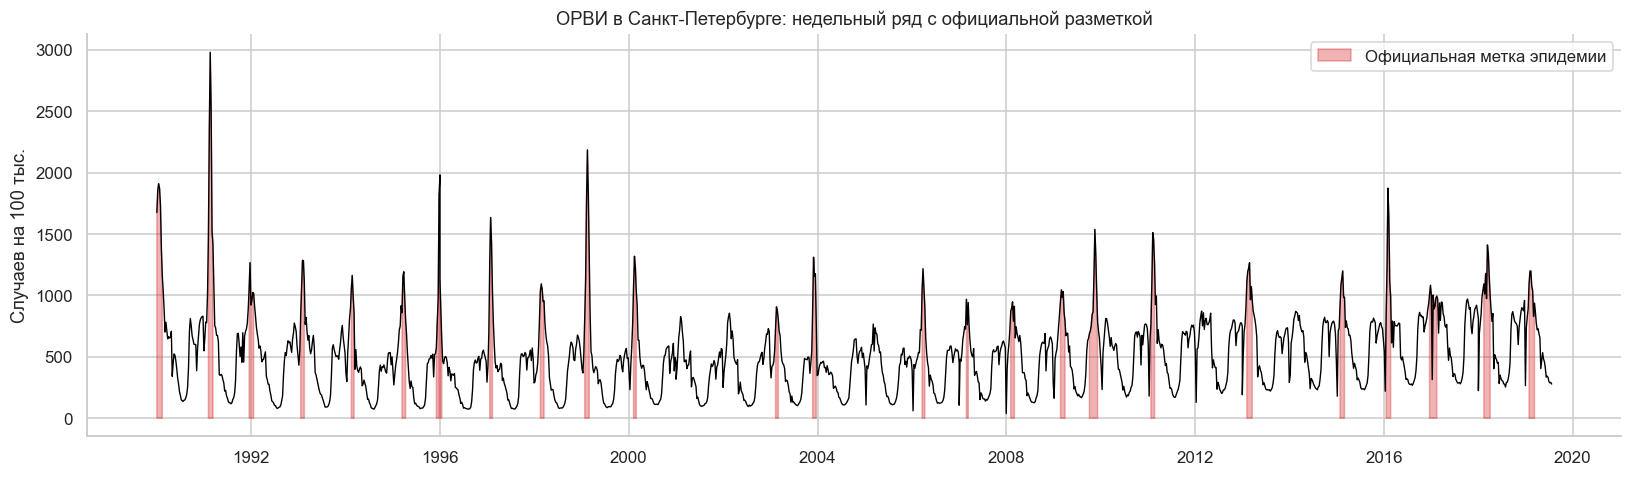

In [53]:
orvi_summary = pd.Series(
    {
        "Первая неделя": orvi["date"].min().date(),
        "Последняя размеченная неделя": orvi["date"].max().date(),
        "Недель": len(orvi),
        "Эпидемических недель": int(orvi["epidemic"].sum()),
        "Эпидемических периодов": int(
            ((orvi["epidemic"].eq(1)) & (orvi["epidemic"].shift(fill_value=0).eq(0))).sum()
        ),
        "Пропусков численности населения": int(orvi["population"].isna().sum()),
    },
    name="Значение",
)
display(orvi_summary.to_frame())

fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(orvi["date"], orvi["incidence_per_100k"], color="black", lw=0.9)
ax.fill_between(
    orvi["date"],
    0,
    orvi["incidence_per_100k"],
    where=orvi["epidemic"].eq(1),
    color="tab:red",
    alpha=0.35,
    label="Официальная метка эпидемии",
)
ax.set(title="ОРВИ в Санкт-Петербурге: недельный ряд с официальной разметкой", ylabel="Случаев на 100 тыс.")
ax.legend()
plt.tight_layout()
plt.show()

### 11.3. Классические модели и методы для несбалансированных классов

Гиперпараметры выбираются по PR-AUC на валидационной выборке; тестовая выборка используется один раз.

In [54]:
published_classification = pd.DataFrame(
    [
        (4, "Decision Tree", 0.79, 0.55, 0.65, 0.75),
        (4, "Easy Ensemble", 0.72, 0.93, 0.70, 0.87),
        (4, "RUSBoost", 0.70, 0.89, 0.67, 0.78),
        (4, "Balanced Bagging", 0.80, 0.89, 0.76, 0.84),
        (4, "EWSNet", 0.71, 0.96, 0.70, 0.86),
        (4, "Random Forest", 0.77, 0.89, 0.73, 0.85),
        (5, "Decision Tree", 0.85, 0.78, 0.82, 0.89),
        (5, "Easy Ensemble", 0.78, 0.89, 0.78, 0.92),
        (5, "RUSBoost", 0.75, 0.90, 0.73, 0.90),
        (5, "Balanced Bagging", 0.77, 0.81, 0.75, 0.86),
        (5, "EWSNet", 0.80, 0.86, 0.80, 0.88),
        (5, "Random Forest", 0.77, 0.81, 0.75, 0.90),
    ],
    columns=["horizon_weeks", "model", "Accuracy", "Recall", "F1", "PR-AUC"],
)

classification_results = []
classification_splits = {}
for warning_horizon in [4, 5]:
    features, raw_windows, labels, sample_meta = build_orvi_samples(
        orvi, input_window=30, warning_horizon=warning_horizon
    )
    validation_result, test_result, models, split_indices = fit_with_temporal_validation(
        features, labels
    )
    test_result.insert(0, "horizon_weeks", warning_horizon)
    test_result["n_test"] = len(split_indices[2])
    test_result["test_positive"] = int(labels[split_indices[2]].sum())
    classification_results.append(test_result)
    classification_splits[warning_horizon] = {
        "features": features,
        "raw_windows": raw_windows,
        "labels": labels,
        "metadata": sample_meta,
        "indices": split_indices,
        "models": models,
    }

classification_results = pd.concat(classification_results, ignore_index=True)

### 11.4. EWSNet и сопоставление со статьей

Варианты входа и сведения трех классов к бинарной метке рассматриваются в анализе чувствительности. Основная спецификация задается до сравнения результатов.

In [55]:
# Предварительно обученные веса EWSNet оцениваются без дообучения. В анализе
# чувствительности проверяются способы сведения трех выходных классов к бинарной
# метке и варианты нормирования 120 признаков EWS. Основная спецификация следует
# формуле (4): исходные объединенные признаки EWS и класс Critical Transition.
ewsnet_cache = pd.read_csv(
    resolve_data_file("orvi_ewsnet_predictions.csv"), parse_dates=["end_date"]
)
ewsnet_sensitivity_rows = []
for warning_horizon in [4, 5]:
    _, _, test_idx = classification_splits[warning_horizon]["indices"]
    for preprocessing in sorted(ewsnet_cache["preprocessing"].unique()):
        cache_block = ewsnet_cache.query(
            "horizon_weeks == @warning_horizon and preprocessing == @preprocessing"
        ).reset_index(drop=True)
        for mapping, probability_column in {
            "critical": "p_critical_transition",
            "smooth_or_critical": "p_any_transition",
        }.items():
            scores = classification_scores(
                cache_block["label"],
                cache_block[probability_column],
            )
            ewsnet_sensitivity_rows.append({
                "horizon_weeks": warning_horizon,
                "preprocessing": preprocessing,
                "binary_mapping": mapping,
                **scores,
                "n_test": len(cache_block),
                "test_positive": int(cache_block["label"].sum()),
            })

ewsnet_sensitivity = pd.DataFrame(ewsnet_sensitivity_rows)
primary_ewsnet = ewsnet_sensitivity.query(
    "preprocessing == 'article_features_raw' and binary_mapping == 'critical'"
).copy()
primary_ewsnet["model"] = "EWSNet"
classification_results = pd.concat(
    [
        classification_results,
        primary_ewsnet[
            ["horizon_weeks", "model", "Accuracy", "Precision", "Recall", "F1", "PR-AUC", "n_test", "test_positive"]
        ],
    ],
    ignore_index=True,
)

#### Чувствительность EWSNet к представлению входа

,horizon_weeks,preprocessing,binary_mapping,Accuracy,Precision,Recall,F1,PR-AUC,n_test,test_positive
4,4,incidence_raw,critical,0.235,0.188,1.000,0.316,0.249,136,24
7,4,incidence_zscore,smooth_or_critical,0.176,0.176,1.000,0.300,0.212,136,24
5,4,incidence_raw,smooth_or_critical,0.176,0.176,1.000,0.300,0.178,136,24
0,4,article_features_raw,critical,0.176,0.176,1.000,0.300,0.178,136,24
1,4,article_features_raw,smooth_or_critical,0.176,0.176,1.000,0.300,0.178,136,24
6,4,incidence_zscore,critical,0.176,0.176,1.000,0.300,0.167,136,24
2,4,article_features_zscore,critical,0.176,0.176,1.000,0.300,0.127,136,24
3,4,article_features_zscore,smooth_or_critical,0.176,0.176,1.000,0.300,0.124,136,24
12,5,incidence_raw,critical,0.279,0.234,1.000,0.380,0.270,136,30
15,5,incidence_zscore,smooth_or_critical,0.221,0.221,1.000,0.361,0.240,136,30


,horizon_weeks,model,Accuracy,Precision,Recall,F1,PR-AUC,n_test,test_positive
2,4,Easy Ensemble,0.765,0.423,0.917,0.579,0.713,136,24
1,4,Random Forest,0.801,0.364,0.167,0.229,0.529,136,24
3,4,RUSBoost,0.801,0.000,0.000,0.000,0.447,136,24
0,4,Decision Tree,0.772,0.422,0.792,0.551,0.432,136,24
4,4,Balanced Bagging,0.824,0.500,0.875,0.636,0.415,136,24
10,4,EWSNet,0.176,0.176,1.000,0.300,0.178,136,24
7,5,Easy Ensemble,0.772,0.492,1.000,0.659,0.747,136,30
6,5,Random Forest,0.816,0.647,0.367,0.468,0.595,136,30
9,5,Balanced Bagging,0.824,0.565,0.867,0.684,0.535,136,30
8,5,RUSBoost,0.772,0.485,0.533,0.508,0.478,136,30


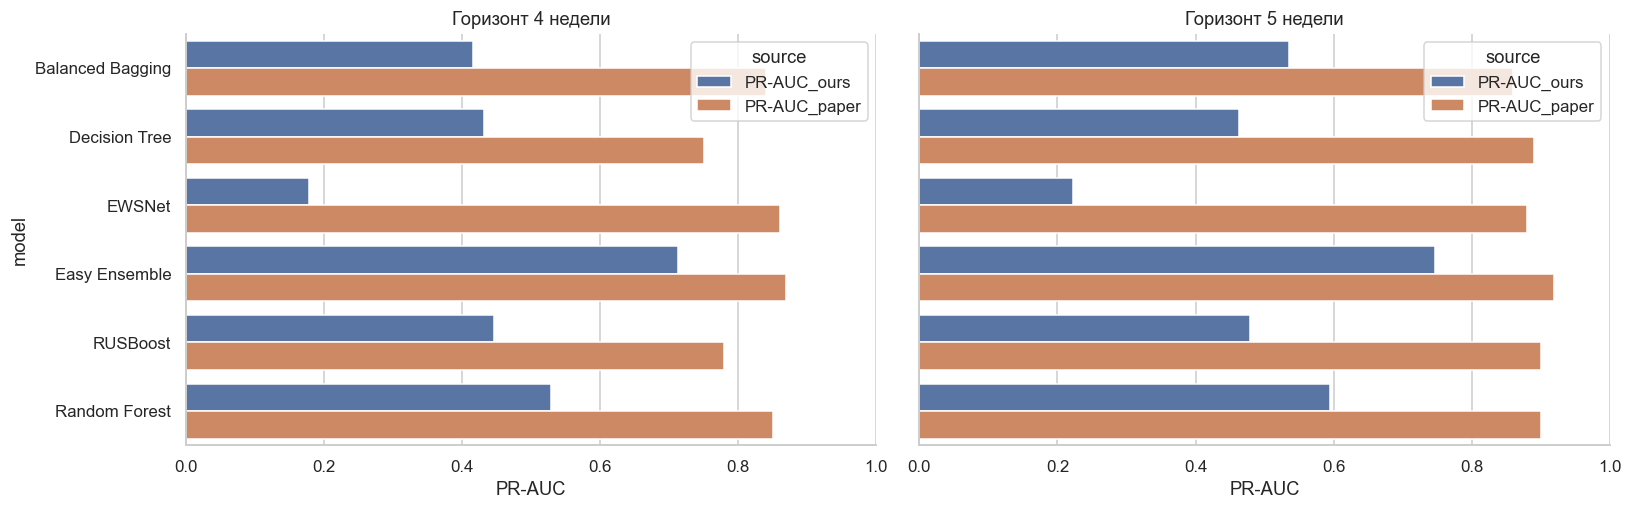

In [56]:
display(
    ewsnet_sensitivity.sort_values(["horizon_weeks", "PR-AUC"], ascending=[True, False])
    .style.format({key: "{:.3f}" for key in ["Accuracy", "Precision", "Recall", "F1", "PR-AUC"]})
)
classification_comparison = classification_results.merge(
    published_classification,
    on=["horizon_weeks", "model"],
    how="outer",
    suffixes=("_ours", "_paper"),
)
display(
    classification_results.sort_values(["horizon_weeks", "PR-AUC"], ascending=[True, False])
    .style.format({key: "{:.3f}" for key in ["Accuracy", "Precision", "Recall", "F1", "PR-AUC"]})
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=True)
for ax, warning_horizon in zip(axes, [4, 5]):
    plot_data = classification_comparison.query("horizon_weeks == @warning_horizon").melt(
        id_vars="model",
        value_vars=["PR-AUC_ours", "PR-AUC_paper"],
        var_name="source",
        value_name="PR-AUC",
    )
    sns.barplot(plot_data, x="PR-AUC", y="model", hue="source", ax=ax)
    ax.set_title(f"Горизонт {warning_horizon} недели")
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

Без дообучения EWSNet относит к переходу почти все эпидемиологические окна. Высокая полнота поэтому сопровождается низкими precision и PR-AUC.

# Часть III. Обсуждение и заключение

## 12. Обсуждение

Рост дисперсии показывает увеличение вариабельности, но не определяет его причину. Оценки $\kappa$ и $\sigma$ позволяют разделить потерю устойчивости и усиление случайных возмущений лишь при достаточной доле успешных оценок и приемлемой неопределенности.

Модели с явным описанием наблюдений устойчивее методов, которые принимают измеренный ряд за истинное состояние. Однако дополнительная сложность помогает не во всех режимах: на коротких и зашумленных окнах гибкие модели часто теряют точность или не сходятся.

**Проверка гипотез:**

- **H1 — поддержана частично.** Совместная оценка $\kappa$ и $\sigma$ специфичнее одной дисперсии, но последовательная тревога сохраняет низкую чувствительность.
- **H2 — поддержана.** SINDy и Neural SDE описывают нелинейный снос, однако на коротких окнах не получают устойчивого преимущества.
- **H3 — поддержана частично.** Явная модель наблюдений повышает долю успешных оценок, но не гарантирует лучшего ROC-AUC.
- **H4 — поддержана.** EWSNet без адаптации плохо переносится с синтетических переходов на ряд ОРВИ.

## 13. Заключение

- Одинаковый рост дисперсии возникает и при снижении локальной устойчивости, и при усилении процессного шума.
- Kalman OU устойчивее метода моментов к редким наблюдениям, шуму измерения и пропускам.
- На нелинейных системах ранжирование методов зависит от формы сноса и режима наблюдений.
- На ряду ОРВИ лучший PR-AUC показал Easy Ensemble: 0,713 для горизонта четыре недели и 0,747 для пяти недель.
- Для COVID-ряда победитель зависит от показателя, горизонта и даты отсечения.

Итог по гипотезам: **H1** и **H3** получили частичную поддержку, а **H2** и **H4** поддержаны результатами экспериментов.

## 14. Ограничения и дальнейшая работа

- Синтетические системы одномерны; не рассматриваются цветной шум, скачки и многомерная частичная наблюдаемость.
- В коротких окнах процессный шум и шум измерения могут быть слабо идентифицируемы.
- SINDy ограничен кубической библиотекой, а интервалы Bayesian SINDy зависят от априорного распределения и эйлеровского приближения.
- Latent Neural SDE использует упрощенное вариационное распределение и небольшую локальную сеть.
- Эпидемиологическая проверка ретроспективна и не заменяет проспективную валидацию.

Следующий этап — проверить чувствительность к длине окна и априорным распределениям, добавить интервалы для различий метрик и повторить анализ на независимых эпидемиологических рядах.
